# Predicción de faltas a consultas médicas (No-show) — Exámen Automatización.




## Resumen inicial del proyecto

### Objetivo
Predecir si un paciente faltará a su consulta médica programada,
utilizando información disponible al momento de la reserva del turno.
Se trata de un problema de **clasificación binaria** con variable objetivo
`Falta a consulta` (Yes = faltó, No = asistió).

---

### El dataset

El dataset fue provisto por el tribunal y contiene registros de turnos
médicos del sistema de salud de Vitória, Brasil (fuente: UTEC).

| Característica | Valor |
|---|---|
| Filas (turnos) | 110.527 |
| Columnas (variables) | 14 |
| Período cubierto | Abril — Junio 2016 |
| Clase mayoritaria | Asiste (≈ 80%) |
| Clase minoritaria | Falta (≈ 20%) |

---

### Descripción de columnas

| Columna | Tipo | Descripción |
|---|---|---|
| `PatientId` | Numérico | Identificador único del paciente (no predictivo) |
| `AppointmentID` | Numérico | Identificador único del turno (no predictivo) |
| `Gender` | Categórico | Género del paciente (M / F) |
| `FechaReserva` | Fecha | Fecha en que se agendó el turno |
| `FechaConsulta` | Fecha | Fecha de la consulta programada |
| `Edad` | Numérico | Edad del paciente en años |
| `Barrio` | Categórico | Barrio de residencia del paciente (81 categorías) |
| `Becado` | Binario | Si el paciente recibe subsidio social (0/1) |
| `Hipertension` | Binario | Si tiene hipertensión (0/1) |
| `Diabetes` | Binario | Si tiene diabetes (0/1) |
| `Alcoholismo` | Binario | Si tiene alcoholismo registrado (0/1) |
| `Discapacidad` | Binario | Si tiene alguna discapacidad (0/1) |
| `Recibió SMS` | Binario | Si recibió recordatorio por SMS (0/1) |
| `Falta a consulta` | Categórico | **Variable objetivo** (Yes = faltó, No = asistió) |

---

### Variables creadas durante el análisis

| Variable nueva | Descripción |
|---|---|
| **dias_espera** | Días entre la reserva y la consulta |
| **faltas_previas** | Tasa histórica de inasistencias del paciente |
| **turnos_previos** | Cantidad de turnos anteriores del paciente |
| **tasa_falta_barrio** | Tasa de ausentismo promedio por barrio |
| **dia_semana** | Día de la semana de la consulta (0=lunes) |

---

### Preguntas que guían el análisis

1. **¿Qué tan desbalanceado está el dataset?**
   ¿La proporción de faltas es suficiente para entrenar modelos confiables?

2. **¿Cuánto influye el tiempo de espera?**
   ¿Los pacientes con turnos más lejanos tienen más probabilidad de faltar?

3. **¿El historial del paciente predice su comportamiento futuro?**
   ¿Un paciente que ya faltó antes tiene más chances de volver a faltar?

4. **¿Hay barrios con mayor tasa de ausentismo?**
   ¿Existen patrones geográficos o socioeconómicos en las inasistencias?

5. **¿El SMS de recordatorio reduce las faltas?**
   ¿Los pacientes que recibieron el aviso tienen mejor adherencia?

6. **¿Qué modelo predice mejor las inasistencias?**
   ¿Cuál es el ROC-AUC máximo alcanzable con los datos disponibles?

7. **¿Cuál es el umbral de clasificación óptimo para uso clínico?**
   ¿Conviene priorizar no perder faltas (recall) o minimizar falsas alarmas (precision)?

### Respuestas obtenidas durante el análisis

**1. ¿Qué tan desbalanceado está el dataset?**
El dataset presenta un desbalance moderado: aproximadamente el **80% de los
pacientes asiste** y el **20% falta**. Este nivel de desbalance es manejable
pero requiere atención: se utilizaron métricas específicas (ROC-AUC y PR-AUC)
en lugar de accuracy, y todos los modelos fueron configurados con parámetros
de compensación de clase (`class_weight="balanced"`, `scale_pos_weight`).

---

**2. ¿Cuánto influye el tiempo de espera?**
`dias_espera` resultó ser **la variable más importante** del modelo según
el análisis de feature importance de XGBoost. A mayor tiempo entre la reserva
y la consulta, mayor probabilidad de inasistencia. Esto es consistente con
la intuición: un turno sacado para dentro de 30 días tiene más chances de
ser olvidado o cancelado que uno para mañana.

---

**3. ¿El historial del paciente predice su comportamiento futuro?**
Sí. `faltas_previas` fue la **tercera variable más importante** del modelo.
Los pacientes con historial de inasistencias tienen significativamente más
probabilidad de volver a faltar. Esta variable fue construida con cuidado
para evitar filtración de datos: solo se usaron turnos anteriores al que
se estaba prediciendo.

---

**4. ¿Hay barrios con mayor tasa de ausentismo?**
Sí. Varios barrios como Santos Dumont, São Pedro e Ilha das Caieiras aparecen
entre las variables más influyentes del modelo. Esto sugiere que existen
factores estructurales — distancia, nivel socioeconómico, acceso a transporte —
que afectan la adherencia según la zona de residencia del paciente.

---

**5. ¿El SMS de recordatorio reduce las faltas?**
Contraintuitivamente, el análisis exploratorio mostró que los pacientes que
recibieron SMS tuvieron una tasa de faltas **ligeramente mayor** que los que
no lo recibieron. Esto no significa que el SMS cause inasistencias: lo más
probable es que el sistema enviara recordatorios con mayor frecuencia a
pacientes de alto riesgo, generando una correlación espuria. `Recibió SMS`
no resultó una variable importante en el modelo final.

---

**6. ¿Qué modelo predice mejor las inasistencias?**
**XGBoost** obtuvo el mejor resultado con un **ROC-AUC de 0.7516** y
**PR-AUC de 0.4247**. Sin embargo, todos los modelos de boosting
convergieron alrededor de 0.75, lo que indica que el techo está dado
por la información disponible en el dataset y no por la elección del
algoritmo. El Dummy Classifier (piso mínimo) obtuvo 0.50, confirmando
que todos los modelos realmente aprenden patrones útiles.

---

**7. ¿Cuál es el umbral de clasificación óptimo para uso clínico?**
El análisis de curva Precision-Recall determinó que el **umbral óptimo
es 0.503**, prácticamente el valor por defecto. En ese punto el modelo
logra un **recall de 0.745** (detecta 3 de cada 4 inasistencias) con una
**precision de 0.336** (1 de cada 3 alertas es correcta). En un contexto
clínico donde el costo de perder una inasistencia supera al de hacer una
llamada extra, este tradeoff es aceptable y el modelo es directamente
utilizable en producción sin ajuste de umbral.

In [73]:
!pip install catboost lightgbm xgboost -q

In [74]:
import os
import sys
import time
import warnings

# ===============================
# MÉTRICAS
# ===============================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)



# --- Manejo de datos
import numpy as np
import pandas as pd

# --- Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    GridSearchCV
)

from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# ===============================
# MODELOS SKLEARN
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)
from sklearn.dummy import DummyClassifier

from sklearn.impute import SimpleImputer

# ===============================
# MODELOS
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.dummy import DummyClassifier
# ===============================
# CONFIG GLOBAL
# ===============================
RANDOM_STATE = 42

# --- Cache / performance
from joblib import Memory, dump, load

# --- Configuración visual
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [75]:
def graficar_faltas(df, columna, y):
    # armo tabla con la columna + si faltó
    tmp = df[[columna]].copy()
    tmp["falto"] = y.values

    # calculo tasa de faltas por categoría
    tasa = tmp.groupby(columna)["falto"].mean()

    # gráfico
    tasa.plot(kind="bar")
    plt.title(f"Tasa de faltas por {columna}")
    plt.ylabel("Tasa de faltas")
    plt.show()


## 1) Carga del dataset

El codigo lee el archivo entregado por el tribunal entorno a faltas en consultas médicas UTEC.


In [76]:


# Cargar dataset
from google.colab import drive
drive.mount('/content/drive')


path = "/content/drive/MyDrive/Faltas a consultas médicas UTEC.xlsx"
df = pd.read_excel(path)

df.head()
print("Shape:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (110527, 14)


,PatientId,AppointmentID,Gender,FechaReserva,FechaConsulta,Edad,Barrio,Becado,Hipertension,Diabetes,Alcoholismo,Discapacidad,Recibió SMS,Falta a consulta
0,29872500000000,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558998000000000,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262960000000,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951000000,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841190000000,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## 2) Limpieza inicial y EDA rápida

Antes de empezar a analizar los datos, hago una copia del dataset original para trabajar con tranquilidad sin correr el riesgo de modificar la fuente.
También aprovecho para limpiar un poco los nombres de las columnas: a veces vienen con espacios de más o saltos de línea y eso después puede generar errores cuando uno intenta usarlas en código o en gráficos.

Por último, uso info() para tener una primera mirada del dataset: cuántas filas hay, qué tipo de datos tiene cada columna y si existen valores faltantes. Es una revisión inicial rápida para entender con qué estamos trabajando.


In [77]:
# Copia de trabajo
df0 = df.copy()

# Normalizar nombres (opcional, pero ayuda)
df0.columns = [c.strip().replace("\n"," ").replace("  "," ") for c in df0.columns]

df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   PatientId         110527 non-null  int64 
 1   AppointmentID     110527 non-null  int64 
 2   Gender            110527 non-null  object
 3   FechaReserva      110527 non-null  object
 4   FechaConsulta     110527 non-null  object
 5   Edad              110527 non-null  int64 
 6   Barrio            110527 non-null  object
 7   Becado            110527 non-null  int64 
 8   Hipertension      110527 non-null  int64 
 9   Diabetes          110527 non-null  int64 
 10  Alcoholismo       110527 non-null  int64 
 11  Discapacidad      110527 non-null  int64 
 12  Recibió SMS       110527 non-null  int64 
 13  Falta a consulta  110527 non-null  object
dtypes: int64(9), object(5)
memory usage: 11.8+ MB


In [78]:
df0.shape


(110527, 14)

En esta línea reviso el tamaño del dataset para tener una idea rápida de su dimensión.

In [79]:
df0.duplicated().sum()

np.int64(0)

Aquí verifico si existen registros duplicados dentro del dataset.

In [80]:
df0.describe()


,PatientId,AppointmentID,Edad,Becado,Hipertension,Diabetes,Alcoholismo,Discapacidad,Recibió SMS
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172615e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173180e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439170e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999820e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


En este paso utilizo describe() para obtener un resumen estadístico general de las variables numéricas del dataset.
Aca podemos ver el mean min max y como esta distribuido cada una de las variables


In [81]:
df0.describe(include="object")


,Gender,FechaReserva,FechaConsulta,Barrio,Falta a consulta
count,110527,110527,110527,110527,110527
unique,2,103549,27,81,2
top,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,JARDIM CAMBURI,No
freq,71840,24,4692,7717,88208


Aca obtengo un resumen de las variables categóricas del dataset, es decir, aquellas que están en formato de texto.
Esto me permite ver cuántos valores únicos tiene cada columna, cuál es el valor más frecuente y con qué frecuencia aparece.

In [82]:
df0["Falta a consulta"].value_counts()


,count
Falta a consulta,
No,88208
Yes,22319


Mi variable objetivo presenta un desbalance: la mayoría de los pacientes asiste a la consulta y una proporción menor falta.
En este caso, el desbalance no es necesariamente un problema, sino que refleja la realidad del sistema de salud: lo normal es que la mayoría de las personas sí concurra a su turno.

In [83]:
df0["Falta a consulta"].value_counts(normalize=True)


,proportion
Falta a consulta,
No,0.798067
Yes,0.201933


Aquí calculo la proporción de cada categoría en la variable “Falta a consulta”.
A diferencia del anterior, esta vez veo los valores en porcentaje, lo que permite entender con mayor claridad qué tan frecuente es cada caso dentro del total de consultas.

In [84]:
df0["y"] = df0["Falta a consulta"].map({"No":0,"Yes":1})


Se crea la variable y para transformar la columna “Falta a consulta” en un formato numérico y que de esta manera pueda ser utilizado por los modelos de machine learning.

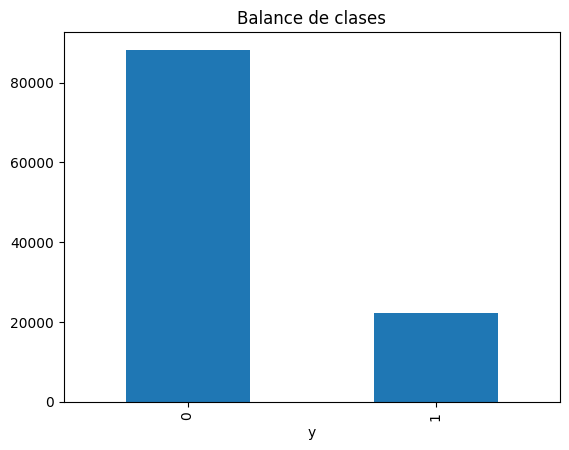

In [85]:
df0["y"].value_counts().plot(kind="bar")
plt.title("Balance de clases")
plt.show()


En este paso grafico la distribución de la variable objetivo y.
El gráfico de barras permite ver de forma visual cuántos pacientes faltaron a consulta

In [86]:
df0.corr(numeric_only=True)


,PatientId,AppointmentID,Edad,Becado,Hipertension,Diabetes,Alcoholismo,Discapacidad,Recibió SMS,y
PatientId,1.000000,0.004039,-0.004139,-0.002880,-0.006441,0.001605,0.011011,-0.007916,-0.009749,-0.001461
AppointmentID,0.004039,1.000000,-0.019126,0.022615,0.012752,0.022628,0.032944,0.014106,-0.256618,-0.162602
Edad,-0.004139,-0.019126,1.000000,-0.092457,0.504586,0.292391,0.095811,0.078033,0.012643,-0.060319
Becado,-0.002880,0.022615,-0.092457,1.000000,-0.019729,-0.024894,0.035022,-0.008586,0.001194,0.029135
Hipertension,-0.006441,0.012752,0.504586,-0.019729,1.000000,0.433086,0.087971,0.080083,-0.006267,-0.035701
Diabetes,0.001605,0.022628,0.292391,-0.024894,0.433086,1.000000,0.018474,0.057530,-0.014550,-0.015180
Alcoholismo,0.011011,0.032944,0.095811,0.035022,0.087971,0.018474,1.000000,0.004648,-0.026147,-0.000196
Discapacidad,-0.007916,0.014106,0.078033,-0.008586,0.080083,0.057530,0.004648,1.000000,-0.024161,-0.006076
Recibió SMS,-0.009749,-0.256618,0.012643,0.001194,-0.006267,-0.014550,-0.026147,-0.024161,1.000000,0.126431
y,-0.001461,-0.162602,-0.060319,0.029135,-0.035701,-0.015180,-0.000196,-0.006076,0.126431,1.000000


A partir de la matriz de correlación se puede observar qué tan relacionadas están las variables numéricas entre sí y con la variable objetivo (y, que representa la falta a consulta).

En general, las correlaciones con la variable objetivo son bajas. Esto es esperable en problemas de comportamiento humano, donde no suele haber una única variable que explique por sí sola la inasistencia. Más bien, la falta a consulta suele depender de varios factores combinados.

Se observa que la edad tiene cierta relación con algunas condiciones de salud como hipertensión y diabetes, lo cual es lógico desde el punto de vista clínico. Sin embargo, estas variables por sí solas no muestran una correlación fuerte con la falta a consulta.

También se ve una relación moderada entre haber recibido SMS y la variable objetivo, lo que sugiere que el recordatorio podría tener algún efecto, aunque no determinante.

En resumen, la matriz de correlación indica que no hay una variable única que explique claramente la inasistencia, por lo que será necesario utilizar modelos de machine learning que puedan capturar relaciones más complejas entre múltiples variables al mismo tiempo.

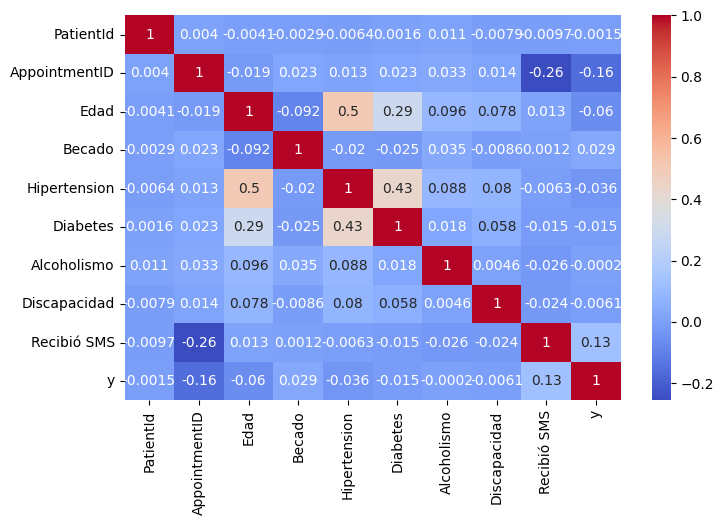

In [87]:
plt.figure(figsize=(8,5))
sns.heatmap(df0.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


Con este grafico logramos visualizar lo que antes describimos de manera grafica y no en una tabla.

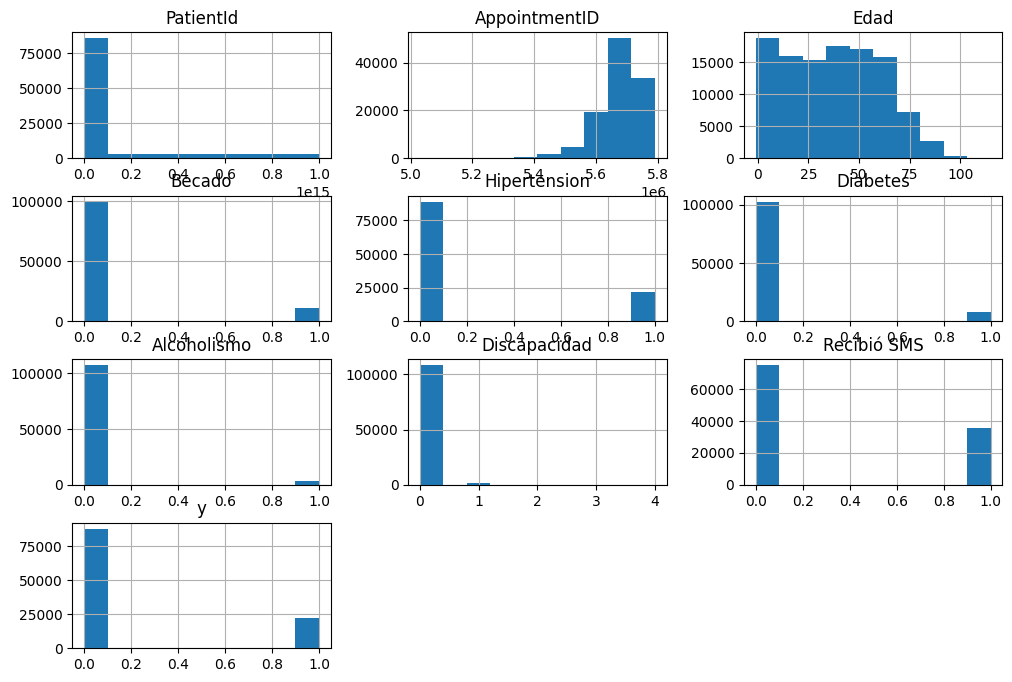

In [88]:
df0.hist(figsize=(12,8))
plt.show()


En esta etapa se grafican los histogramas de las variables numéricas para observar cómo se distribuyen los datos.
Esto permite tener una idea visual de los rangos de valores, la concentración de los datos y la posible presencia de valores extremos.

Se puede ver que muchas variables son binarias (por ejemplo: becado, hipertensión, diabetes, alcoholismo o si recibió SMS), por lo que se concentran principalmente en los valores 0 y 1.
La edad presenta una distribución más variada y razonable, con mayor concentración en edades adultas.

También se observa que los identificadores como PatientId y AppointmentID no aportan información relevante para el análisis, ya que son solo números únicos asociados a cada registro. Estas variables se eliminarán más adelante antes de entrenar los modelos.

En general, este paso ayuda a comprender la estructura de los datos y a detectar posibles valores atípicos o variables que no aportan valor predictivo

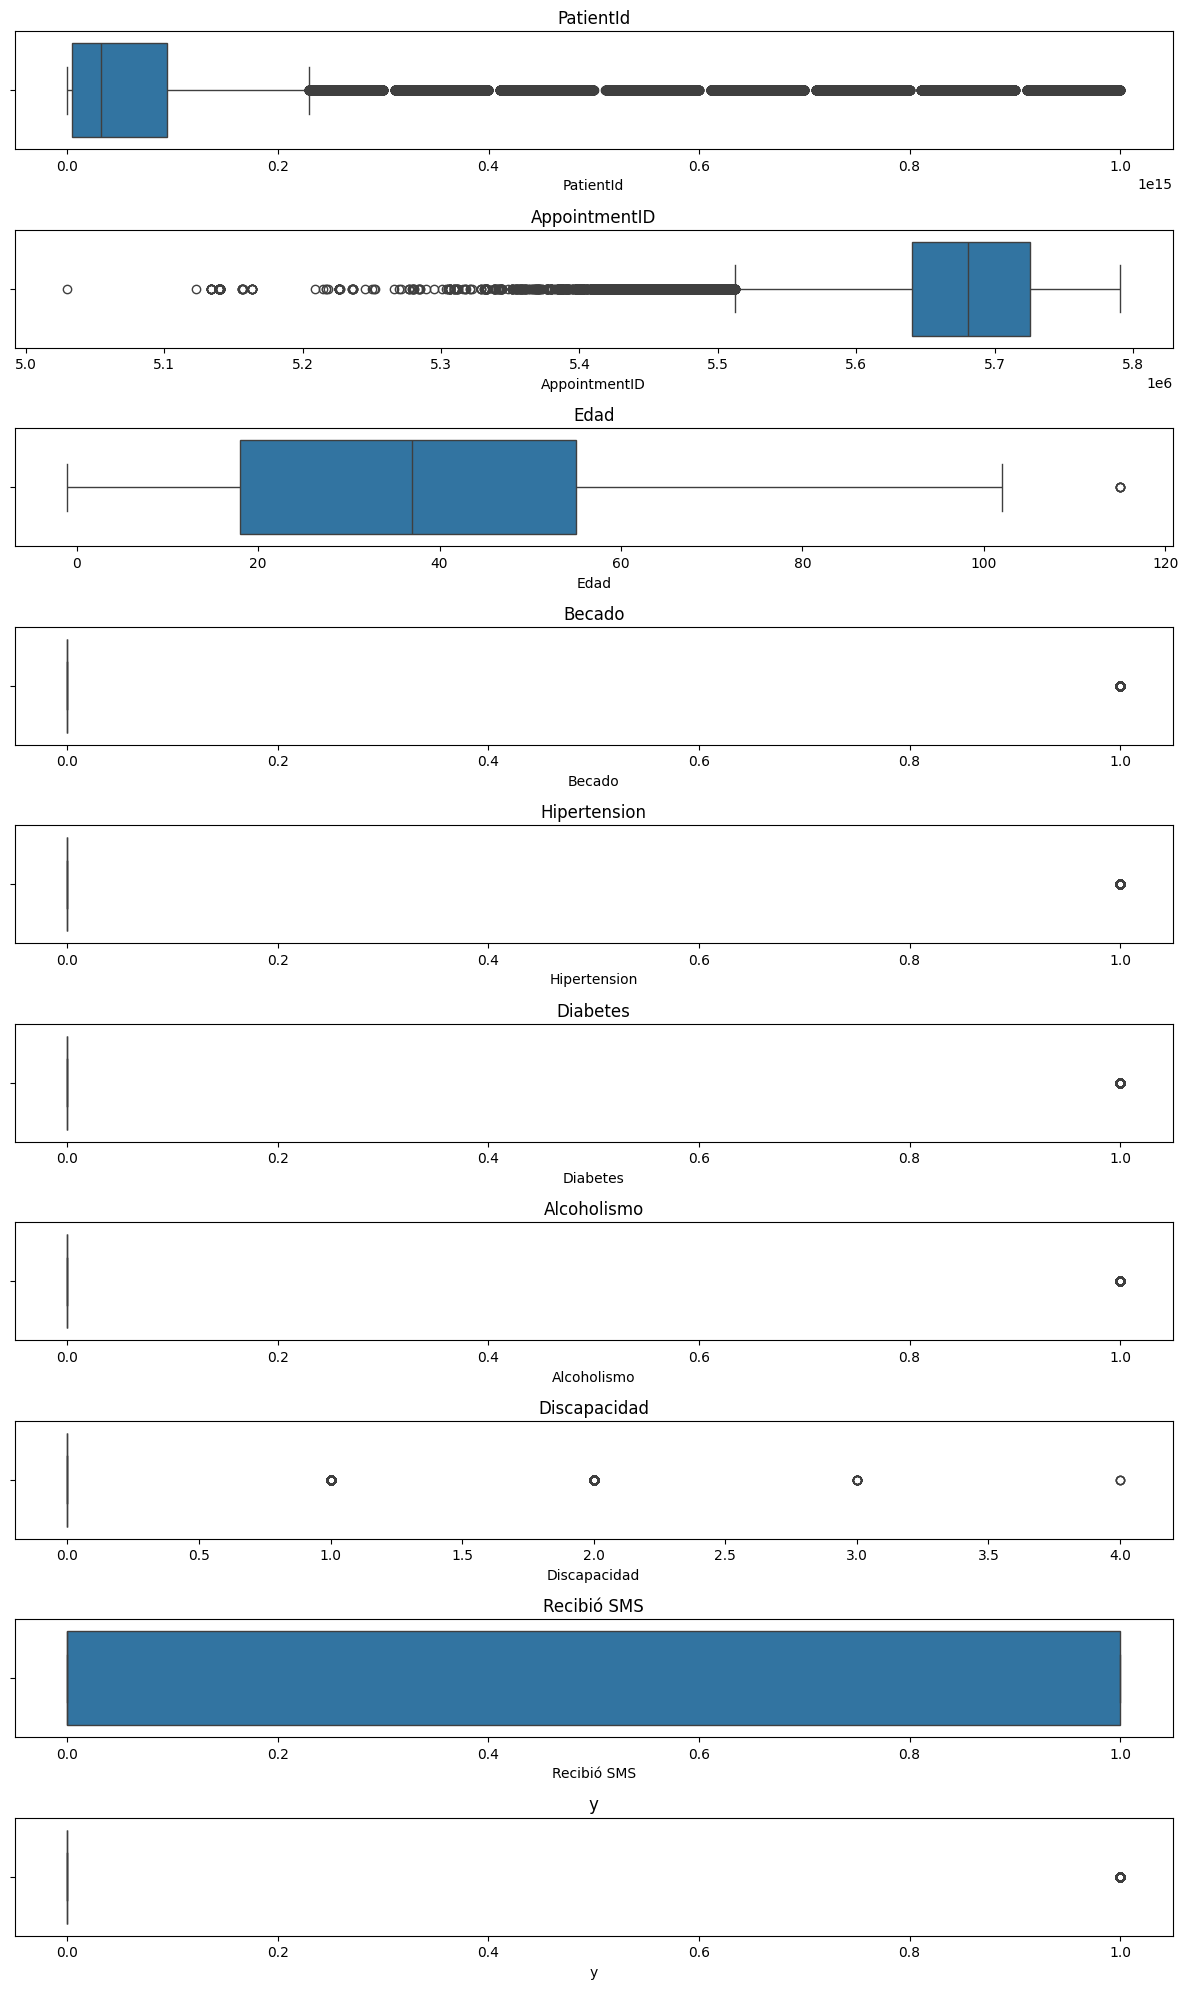

In [89]:
cols = df0.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(12, len(cols)*2))  # altura dinámica

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    sns.boxplot(x=df0[col])
    plt.title(col)

plt.tight_layout()
plt.show()


En este paso se generan boxplots para cada variable numérica con el objetivo de detectar valores atípicos.
Los diagramas de caja permiten ver la distribución de los datos, la mediana y posibles valores extremos que se alejan del comportamiento general.

Se observa que muchas variables son binarias (0 y 1), por lo que en esos casos los boxplots no aportan demasiada información y es normal que se vean concentrados en dos valores.
Sin embargo, en variables como la edad o el tiempo de espera pueden aparecer valores más alejados del rango habitual, lo que sirve para evaluar si es necesario realizar algún tipo de limpieza o ajuste.

Este análisis ayuda a decidir qué variables requieren tratamiento de outliers y cuáles pueden mantenerse tal como están antes de entrenar los modelos.

In [90]:
# edad a número
df0["Edad"] = pd.to_numeric(df0["Edad"], errors="coerce")

# filtrar edad válida
df0 = df0[(df0["Edad"] >= 0) & (df0["Edad"] <= 100)]

# crear wait_days si no existe
df0["FechaReserva"] = pd.to_datetime(df0["FechaReserva"], dayfirst=True, errors="coerce")
df0["FechaConsulta"] = pd.to_datetime(df0["FechaConsulta"], dayfirst=True, errors="coerce")

df0["wait_days"] = (df0["FechaConsulta"] - df0["FechaReserva"]).dt.days


df0["wait_days"] = df0["wait_days"].clip(upper=90)



In [91]:
df0.isna().mean().sort_values(ascending=False).head(10)

,0
PatientId,0.0
AppointmentID,0.0
Gender,0.0
FechaReserva,0.0
FechaConsulta,0.0
Edad,0.0
Barrio,0.0
Becado,0.0
Hipertension,0.0
Diabetes,0.0


En este paso reviso el porcentaje de valores faltantes en cada columna del dataset.
En lugar de ver solo la cantidad de nulos, calculo la proporción respecto al total de registros, lo que permite dimensionar mejor qué tan grande es el problema en cada variable.

Ordenar las columnas de mayor a menor porcentaje de valores faltantes ayuda a identificar rápidamente cuáles requieren algún tratamiento, ya sea imputación, eliminación o revisión.
Este chequeo es importante antes de entrenar modelos, ya que los algoritmos de machine learning no pueden trabajar directamente con valores nulos.

In [92]:
# Target: 'Falta a consulta' suele venir como Yes/No (o 1/0). Lo llevamos a 1=Falta, 0=Asiste.
col = "Falta a consulta"

y_raw = df0[col]

if y_raw.dtype == "O":
    y = y_raw.astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})
else:
    y = y_raw.astype(int)

if y.isna().any():
    # Si hubiera otros valores, los mostramos
    print("Valores no mapeados en target:", sorted(set(y_raw[y.isna()].astype(str)))[:10])
    raise ValueError("Target tiene valores inesperados; revisá el mapeo.")

print("Distribución target (0=Asiste, 1=Falta):")
display(y.value_counts())
print("Tasa de faltas:", y.mean().round(4))


Distribución target (0=Asiste, 1=Falta):


,count
Falta a consulta,
0,88203
1,22316


Tasa de faltas: 0.2019


En este bloque preparo la variable objetivo del modelo.
La columna “Falta a consulta” suele venir en formato texto (Yes/No), por lo que se transforma a formato numérico:
1 = falta a la consulta y 0 = asiste.

Esto es necesario porque los modelos de machine learning trabajan con variables numéricas.
Además, se verifica que no existan valores inesperados en la columna; si apareciera algo distinto de “Yes” o “No”, el código lo detecta para poder revisarlo antes de continuar.

Por último, se muestra la distribución de la variable objetivo y la tasa general de faltas.
Esto permite entender qué proporción de pacientes no se presenta a su turno y sirve como referencia inicial para evaluar luego el desempeño del modelo.

In [93]:
# Revisiones rápidas de columnas clave
cols_show = ["Gender","Edad","Barrio","Becado","Hipertension","Diabetes","Alcoholismo","Discapacidad","Recibió SMS"]
for c in cols_show:
    if c in df0.columns:
        print("\n===", c, "===")
        display(df0[c].value_counts(dropna=False).head(10))



=== Gender ===


,count
Gender,
F,71832
M,38687



=== Edad ===


,count
Edad,
0,3539
1,2273
52,1746
49,1652
53,1651
56,1635
38,1629
59,1624
2,1618



=== Barrio ===


...

,count
Alcoholismo,
0,107159
1,3360



=== Discapacidad ===


,count
Discapacidad,
0,108282
1,2038
2,183
3,13
4,3



=== Recibió SMS ===


,count
Recibió SMS,
0,75038
1,35481


En este bloque reviso rápidamente algunas columnas clave del dataset para entender cómo están distribuidos sus valores.
La idea es observar las categorías más frecuentes en variables importantes como género, barrio, condiciones de salud o si el paciente recibió SMS.

Esto permite detectar posibles inconsistencias, valores mal cargados o categorías inesperadas antes de continuar con el análisis.
También ayuda a conocer mejor la composición de la población de pacientes y a tener una primera idea de qué variables podrían ser relevantes para el modelo.

### 2.1) Parseo de fechas y chequeo de consistencia

Una variable crucial es el **tiempo de espera** (días entre reserva y consulta).  
Si hay reservas después de la consulta (sí, pasa), lo marcamos y decidimos qué hacer.


In [94]:
# Parseo robusto de fechas
for c in ["FechaReserva","FechaConsulta"]:
    if c in df0.columns:
        df0[c] = pd.to_datetime(df0[c], errors="coerce")

df0[["FechaReserva","FechaConsulta"]].isna().mean()


,0
FechaReserva,0.0
FechaConsulta,0.0


En este paso se convierten las columnas de fechas al formato adecuado para poder trabajar con ellas correctamente.
A veces las fechas vienen como texto o con formatos inconsistentes, por lo que se utiliza una conversión robusta que transforma los valores válidos y marca como nulos aquellos que no pueden interpretarse como fechas.

Luego se revisa el porcentaje de valores faltantes en ambas columnas.
Esto permite verificar si hubo registros que no pudieron convertirse correctamente y dimensionar si es necesario aplicar algún tratamiento adicional antes de continuar con el análisis.

In [95]:
# Tiempo de espera (en días)
df0["wait_days"] = (df0["FechaConsulta"] - df0["FechaReserva"]).dt.total_seconds() / (24*3600)

# Casos con fechas inconsistentes
bad_wait = (df0["wait_days"] < 0) | (df0["wait_days"].isna())
print("Registros con wait_days < 0 o NaN:", bad_wait.mean().round(4))

df0.loc[bad_wait, ["FechaReserva","FechaConsulta","wait_days"]].head()


Registros con wait_days < 0 o NaN: 0.3489


,FechaReserva,FechaConsulta,wait_days
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,-0.776481
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,-0.672535
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,-0.679907
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,-0.728831
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,-0.671794


En este bloque se calcula el tiempo de espera entre la fecha en que el paciente reservó el turno y la fecha de la consulta.
Esta nueva variable (wait_days) representa la cantidad de días que el paciente tuvo que esperar y es relevante porque el tiempo de espera suele influir en la probabilidad de que una persona falte.

Luego se identifican registros con valores problemáticos:

tiempos de espera negativos (por ejemplo, si la fecha de consulta aparece antes que la de reserva),

o valores faltantes en las fechas.

Se calcula qué proporción del dataset presenta estas inconsistencias y se muestran algunos ejemplos para revisar.
Esto permite detectar errores en la carga de datos y decidir cómo tratarlos antes de continuar con el modelado.

#EDA

En este paso se verifica que la columna “Falta a consulta” esté presente en el dataset antes de continuar con el análisis.
Esto es una validación preventiva: si la columna no existe o tiene un nombre distinto, el código lo detecta y detiene la ejecución para evitar errores más adelante.

También se imprime la lista de columnas disponibles en el dataframe.
Esto sirve para confirmar que los nombres de las variables son los esperados y para detectar posibles diferencias en la forma en que están escritas (por ejemplo, espacios extra o cambios de nombre).


In [96]:
COL = "Falta a consulta"

df0 = df0.copy()

if COL not in df0.columns:
    raise KeyError(f"No encuentro '{COL}'. Columnas: {list(df0.columns)}")

print(list(df0.columns))

['PatientId', 'AppointmentID', 'Gender', 'FechaReserva', 'FechaConsulta', 'Edad', 'Barrio', 'Becado', 'Hipertension', 'Diabetes', 'Alcoholismo', 'Discapacidad', 'Recibió SMS', 'Falta a consulta', 'y', 'wait_days']


In [97]:
y = df0[COL].astype(str).str.strip().str.lower().map({"no": 0, "yes": 1})

if y.isna().any():
    raros = df0.loc[y.isna(), COL].unique()

print("Distribución target (0=asiste, 1=falta):")
print(y.value_counts())
print("\nProporciones:")
print(y.value_counts(normalize=True))


Distribución target (0=asiste, 1=falta):
Falta a consulta
0    88203
1    22316
Name: count, dtype: int64

Proporciones:
Falta a consulta
0    0.79808
1    0.20192
Name: proportion, dtype: float64


En este bloque se transforma la variable “Falta a consulta” a formato numérico para poder utilizarla como variable objetivo del modelo.
Se estandariza el texto (se eliminan espacios y se pasa todo a minúsculas) y luego se convierte a valores binarios:

**0 = el paciente asiste**

**1 = el paciente falta**

También se realiza una validación para detectar si existen valores inesperados en la columna.

Esto permite entender qué porcentaje de pacientes falta a la consulta y tener una referencia clara sobre el desbalance del dataset antes de entrenar los modelos.

In [98]:
for col in ["FechaReserva", "FechaConsulta"]:
    if col in df0.columns:
        df0[col] = pd.to_datetime(df0[col], errors="coerce", dayfirst=True)

print("Tipos de fechas:")
print(df0[["FechaReserva","FechaConsulta"]].dtypes)


Tipos de fechas:
FechaReserva     datetime64[ns, UTC]
FechaConsulta    datetime64[ns, UTC]
dtype: object


En este paso se convierten las columnas de fechas al formato adecuado para poder trabajar con ellas correctamente.

In [99]:
if "FechaReserva" in df0.columns and "FechaConsulta" in df0.columns:
    df0["dias_espera"] = (df0["FechaConsulta"] - df0["FechaReserva"]).dt.total_seconds() / (3600*24)
    print(df0["dias_espera"].describe())


count    110519.000000
mean          9.714465
std          15.244249
min          -6.575926
25%          -0.346157
50%           3.474537
75%          14.320538
max         178.554873
Name: dias_espera, dtype: float64


En este paso se crea una nueva variable llamada “dias_espera”, que representa la cantidad de días entre la reserva del turno y la fecha de la consulta.
Esta variable es relevante porque el tiempo de espera puede influir en la probabilidad de que un paciente se presente o no a su turno.

In [100]:
df0["FechaReserva"] = pd.to_datetime(df0["FechaReserva"], dayfirst=True, errors="coerce")
df0["FechaConsulta"] = pd.to_datetime(df0["FechaConsulta"], dayfirst=True, errors="coerce")


En este paso se aseguran las columnas de fechas en el formato correcto.
Tanto la fecha de reserva como la fecha de la consulta se convierten a tipo fecha para poder utilizarlas en cálculos y análisis posteriores.

In [101]:
df0["falto"] = df0["Falta a consulta"].map({"No":0,"Yes":1})

reservas = (
    df0["FechaReserva"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
    .rename("Reservas")
)

consultas = (
    df0["FechaConsulta"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
    .rename("Consultas")
)

faltas = (
    df0.groupby(df0["FechaConsulta"].dt.to_period("M"))["falto"]
    .sum()
    .rename("Faltas")
)

tasa = (
    df0.groupby(df0["FechaConsulta"].dt.to_period("M"))["falto"]
    .mean()
    .rename("Tasa_faltas")
)


tabla_mensual = pd.concat([reservas, consultas, faltas, tasa], axis=1)

tabla_mensual = tabla_mensual.reset_index()
tabla_mensual.columns = ["Mes", "Reservas", "Consultas", "Faltas", "Tasa_faltas"]

tabla_mensual


,Mes,Reservas,Consultas,Faltas,Tasa_faltas
0,2015-11,1,NaN,NaN,NaN
1,2015-12,61,NaN,NaN,NaN
2,2016-01,60,NaN,NaN,NaN
3,2016-02,281,NaN,NaN,NaN
4,2016-03,3614,NaN,NaN,NaN
5,2016-04,25338,3235.0,633.0,0.195672
6,2016-05,67415,80836.0,16801.0,0.207841
7,2016-06,13749,26448.0,4882.0,0.184589


Este bloque construye una tabla mensual con volumen y faltas. Con la salvedad de que usa dos “bases de mes” distintas (reservas por FechaReserva, consultas/faltas por FechaConsulta) y asume que Falta a consulta trae exactamente "No"/"Yes".

In [102]:
# convertir fechas
df0["FechaReserva"] = pd.to_datetime(df0["FechaReserva"], dayfirst=True)
df0["FechaConsulta"] = pd.to_datetime(df0["FechaConsulta"], dayfirst=True)

# índice único de meses (consulta es la base)
meses = df0["FechaConsulta"].dt.to_period("M")

Se convierten las columnas de fechas al tipo datetime para poder trabajar correctamente con ellas en el análisis temporal.
Luego se construye una referencia de meses a partir de la fecha de consulta, que será la base temporal principal del estudio.

Esto permite unificar los cálculos mensuales (consultas, faltas, tasas, etc.) usando el mismo eje de tiempo y evitar desalineaciones entre meses al momento de graficar o construir tablas.

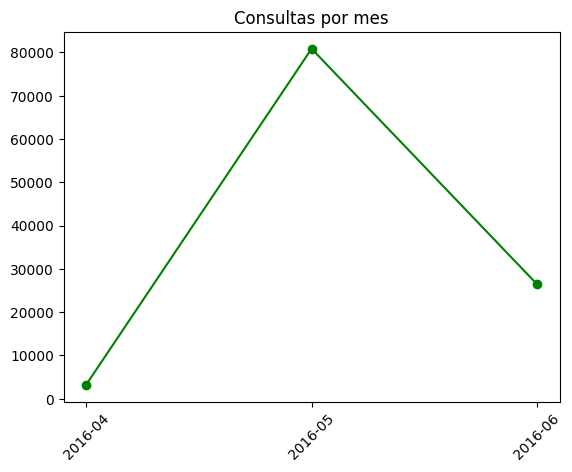

In [103]:
consultas_mes = df0.groupby(df0["FechaConsulta"].dt.to_period("M")).size()
consultas_mes = consultas_mes.reindex(meses.sort_values().unique())

plt.plot(meses.sort_values().unique().astype(str), consultas_mes.values, marker="o", color="green")
plt.title("Consultas por mes")
plt.xticks(rotation=45)
plt.show()


En este bloque se calcula la cantidad de consultas por mes tomando como referencia la fecha de consulta.
Primero se agrupan los registros por mes y se cuentan las consultas en cada período. Luego se reindexa la serie para asegurar que todos los meses presentes en el dataset queden alineados en el mismo eje temporal.

Finalmente, se genera un gráfico de líneas que muestra la evolución mensual de las consultas.
Este gráfico permite visualizar tendencias, detectar meses con mayor o menor demanda y entender la dinámica temporal de las consultas médicas.

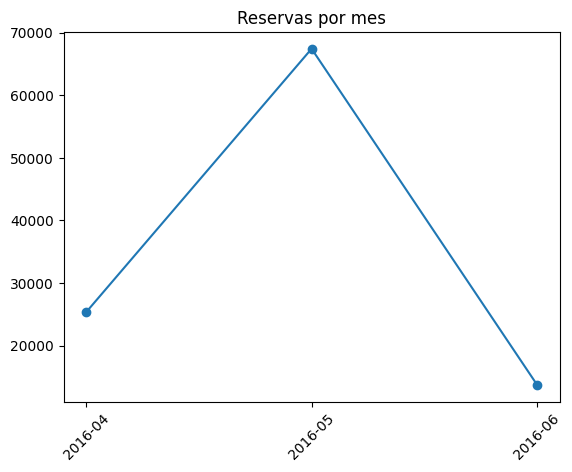

In [104]:
reservas_mes = df0.groupby(df0["FechaReserva"].dt.to_period("M")).size()
reservas_mes = reservas_mes.reindex(meses.sort_values().unique())

plt.plot(meses.sort_values().unique().astype(str), reservas_mes.values, marker="o")
plt.title("Reservas por mes")
plt.xticks(rotation=45)
plt.show()


En este bloque se calcula la cantidad de reservas realizadas por mes utilizando la fecha de reserva.
Se agrupan los registros por mes y se cuentan las reservas en cada período. Luego se alinean los meses con la misma referencia temporal utilizada anteriormente, para que las comparaciones entre gráficos sean consistentes.

Finalmente, se genera un gráfico de líneas que muestra la evolución mensual de las reservas.
Esto permite observar cómo varía la demanda de turnos a lo largo del tiempo y compararla posteriormente con la cantidad de consultas efectivamente realizadas y las faltas.

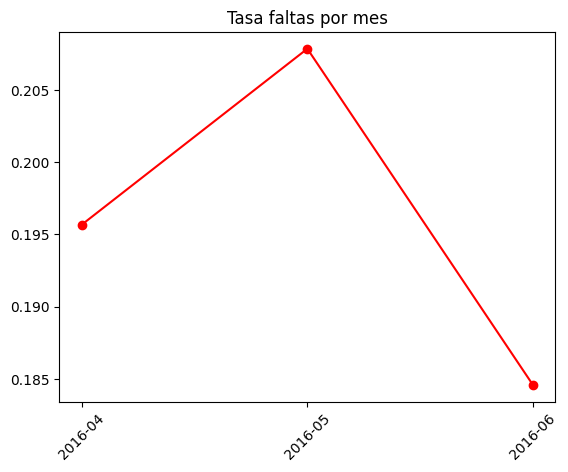

In [105]:
faltas_mes = df0.groupby(df0["FechaConsulta"].dt.to_period("M"))["y"].mean()
faltas_mes = faltas_mes.reindex(meses.sort_values().unique())

plt.plot(meses.sort_values().unique().astype(str), faltas_mes.values, marker="o", color="red")
plt.title("Tasa faltas por mes")
plt.xticks(rotation=45)
plt.show()


En este bloque se calcula la tasa de faltas por mes.
Primero se transforma la variable “Falta a consulta” a formato numérico (0 = asiste, 1 = falta) para poder trabajarla de forma cuantitativa.

Luego se agrupan los registros por mes según la fecha de la consulta y se calcula el promedio de la variable y.
Al ser una variable binaria, este promedio representa la proporción de pacientes que no se presentaron en cada mes.

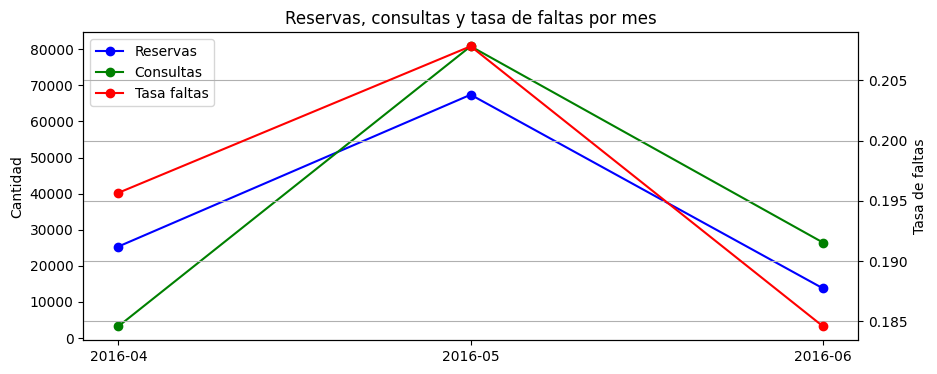

In [106]:
fig, ax1 = plt.subplots(figsize=(10,4))

# Ensure idx is the common index for all monthly data
idx = meses.sort_values().unique()

# eje izquierdo
l1 = ax1.plot(idx.astype(str), reservas_mes.values, marker="o", color="blue", label="Reservas")
l2 = ax1.plot(idx.astype(str), consultas_mes.values, marker="o", color="green", label="Consultas")
ax1.set_ylabel("Cantidad")

# eje derecho
ax2 = ax1.twinx()
l3 = ax2.plot(idx.astype(str), faltas_mes.values, marker="o", color="red", label="Tasa faltas")
ax2.set_ylabel("Tasa de faltas")


lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.xticks(rotation=45)
plt.title("Reservas, consultas y tasa de faltas por mes")
plt.grid(True)
plt.show()

En este gráfico se combinan tres series mensuales en una sola visualización: la cantidad de reservas, la cantidad de consultas y la tasa de faltas.
Las reservas y consultas se muestran en el eje izquierdo, mientras que la tasa de inasistencia se representa en el eje derecho para poder comparar magnitudes distintas en el mismo gráfico.

Se utiliza un mismo eje temporal para las tres series, lo que permite observar de forma conjunta cómo evoluciona la demanda de turnos, la cantidad de consultas realizadas y la proporción de pacientes que no se presentan.
Esta visualización ayuda a identificar patrones temporales y posibles relaciones entre el volumen de consultas y las faltas a lo largo de los meses.

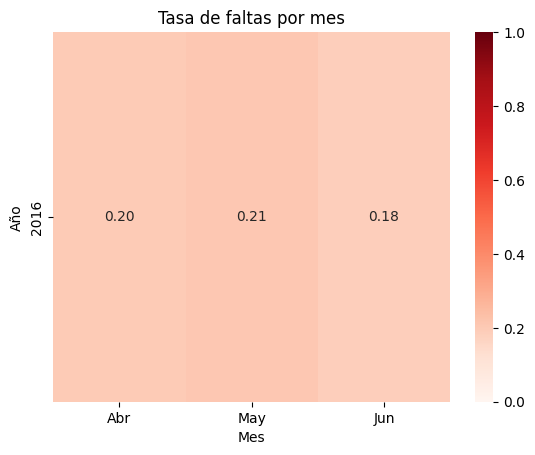

In [107]:
df0["FechaConsulta"] = pd.to_datetime(df0["FechaConsulta"], dayfirst=True, errors="coerce")
# df0["y"] = df0["Falta a consulta"].astype(str).str.strip().str.lower().map({"no":0, "yes":1})

tabla = df0.dropna(subset=["FechaConsulta","y"]).pivot_table(
    values="y",
    index=df0["FechaConsulta"].dt.year,
    columns=df0["FechaConsulta"].dt.month,
    aggfunc="mean"
)

meses_map = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}
tabla = tabla.rename(columns=meses_map)

sns.heatmap(tabla, annot=True, cmap="Reds", fmt=".2f", vmin=0, vmax=1)
plt.title("Tasa de faltas por mes")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()


En este bloque se construye un mapa de calor para visualizar la tasa de faltas según el mes y el año de la consulta.
Primero se convierten las fechas al formato correcto y se transforma la variable de inasistencia a formato numérico (0 = asiste, 1 = falta). Luego se eliminan registros con valores faltantes en estas variables.

A continuación, se crea una tabla dinámica donde cada fila representa un año y cada columna un mes. En cada celda se calcula el promedio de la variable de faltas, lo que equivale a la proporción de pacientes que no asistieron en ese período.

Finalmente, se genera un mapa de calor que permite observar de forma visual en qué meses y años se concentran mayores tasas de inasistencia. Esta representación facilita la detección de patrones temporales y posibles estacionalidades en el comportamiento de los pacientes.

#Feature Engeneering


In [108]:
# =================================
# FEATURE TIEMPO DE ESPERA
# =================================
df0["dias_espera"] = (df0["FechaConsulta"] - df0["FechaReserva"]).dt.days
df0.loc[df0["dias_espera"] < 0, "dias_espera"] = np.nan
df0["dias_espera"] = df0["dias_espera"].clip(0,90)

df0["log_dias_espera"] = np.log1p(df0["dias_espera"])

# =================================
# ESTACIONALIDAD
# =================================
df0["consulta_mes"] = df0["FechaConsulta"].dt.month
df0["consulta_dow"] = df0["FechaConsulta"].dt.dayofweek

df0["mes_sin"] = np.sin(2*np.pi*df0["consulta_mes"]/12)
df0["mes_cos"] = np.cos(2*np.pi*df0["consulta_mes"]/12)

df0["dow_sin"] = np.sin(2*np.pi*df0["consulta_dow"]/7)
df0["dow_cos"] = np.cos(2*np.pi*df0["consulta_dow"]/7)

En este bloque se realiza una limpieza básica de los datos para dejarlos listos para el modelado.

Primero se eliminan las columnas de identificadores (PatientId y AppointmentID) ya que no aportan información útil para predecir la inasistencia: solo identifican registros individuales y podrían generar ruido en el modelo.

Luego se asegura que la variable edad esté en formato numérico y se filtran valores fuera de un rango razonable (entre 0 y 100 años), evitando asi posible errores y

Después se convierten las columnas de fechas al formato correcto para poder trabajar con ellas. A partir de estas fechas se crea una nueva variable llamada wait_days, que representa la cantidad de días entre la reserva del turno y la fecha de la consulta. Esta variable es importante porque el tiempo de espera puede influir en la probabilidad de que un paciente falte.

Finalmente, se limita el valor máximo de wait_days a 90 días para evitar que valores extremos afecten el análisis y el entrenamiento del modelo. Esto ayuda a mantener una distribución más estable y realista de los tiempos de espera.

In [109]:
# =================================
# FEATURE TIEMPO DE ESPERA
# =================================
df0["dias_espera"] = (df0["FechaConsulta"] - df0["FechaReserva"]).dt.days
df0["dias_espera"] = df0["dias_espera"].clip(0, 90)
df0["log_dias_espera"] = np.log1p(df0["dias_espera"])

# =================================
# ESTACIONALIDAD
# =================================
df0["consulta_mes"] = df0["FechaConsulta"].dt.month
df0["consulta_dow"] = df0["FechaConsulta"].dt.dayofweek

df0["mes_sin"] = np.sin(2*np.pi*df0["consulta_mes"]/12)
df0["mes_cos"] = np.cos(2*np.pi*df0["consulta_mes"]/12)

df0["dow_sin"] = np.sin(2*np.pi*df0["consulta_dow"]/7)
df0["dow_cos"] = np.cos(2*np.pi*df0["consulta_dow"]/7)

In [110]:
pacientes = df0["PatientId"].unique()

train_p, test_p = train_test_split(
    pacientes,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_df = df0[df0["PatientId"].isin(train_p)].copy()
test_df  = df0[df0["PatientId"].isin(test_p)].copy()

In [111]:
def crear_historial(df):
    df = df.sort_values(["PatientId", "FechaConsulta"]).copy()

    df["faltas_previas"] = (
        df.groupby("PatientId")["y"]
          .shift()
          .fillna(0)
          .groupby(df["PatientId"])
          .cumsum()
    )

    df["ratio_faltas_previas"] = (
        df.groupby("PatientId")["y"]
          .expanding()
          .mean()
          .shift()
          .reset_index(level=0, drop=True)
          .fillna(0)
    )

    return df

train_df = crear_historial(train_df)
test_df  = crear_historial(test_df)

In [112]:
cols_drop = ["Falta a consulta", "y", "FechaReserva", "FechaConsulta"]

X_train = train_df.drop(columns=cols_drop)
y_train = train_df["y"]

X_test  = test_df.drop(columns=cols_drop)
y_test  = test_df["y"]

In [113]:
# =============================
# HISTORIAL DEL PACIENTE
# =============================

df0 = df0.sort_values(["PatientId","FechaConsulta"])

df0["faltas_previas"] = (
    df0.groupby("PatientId")["y"]
    .shift()
    .fillna(0)
    .groupby(df0["PatientId"])
    .cumsum()
)

df0["ratio_faltas_previas"] = (
    df0.groupby("PatientId")["y"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

df0["ratio_faltas_previas"] = df0["ratio_faltas_previas"].fillna(0)

# =============================
# TIEMPO DE ESPERA
# =============================

df0["dias_espera"] = (df0["FechaConsulta"] - df0["FechaReserva"]).dt.days
df0["dias_espera"] = df0["dias_espera"].clip(0,90)

df0["log_dias_espera"] = np.log1p(df0["dias_espera"])

# =============================
# ESTACIONALIDAD
# =============================

df0["consulta_mes"] = df0["FechaConsulta"].dt.month
df0["consulta_dow"] = df0["FechaConsulta"].dt.dayofweek

df0["mes_sin"] = np.sin(2*np.pi*df0["consulta_mes"]/12)
df0["mes_cos"] = np.cos(2*np.pi*df0["consulta_mes"]/12)

df0["dow_sin"] = np.sin(2*np.pi*df0["consulta_dow"]/7)
df0["dow_cos"] = np.cos(2*np.pi*df0["consulta_dow"]/7)

In [114]:
X = df0.drop(columns=[
    "Falta a consulta",
    "y",
    "FechaReserva",
    "FechaConsulta",
    "AppointmentID",
    "PatientId"
])

y = df0["y"]

## 4) Split + pipeline de preprocesamiento

- Split train/test estratificado
- Preprocesamiento con `ColumnTransformer`:
  - numéricas: imputación mediana + escalado (para LogisticRegression)
  - categóricas: imputación + OneHot


In [115]:
columns_to_drop = [
    "Falta a consulta",
    "y",
    "falto",
    "FechaReserva",
    "FechaConsulta",
    "wait_days"
]
X = df0.drop(columns=columns_to_drop)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_features = X_train.select_dtypes(
    include=["int64","float64","int32","float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object","category"]
).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
        dtype=np.float32
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Numéricas: ['PatientId', 'AppointmentID', 'Edad', 'Becado', 'Hipertension', 'Diabetes', 'Alcoholismo', 'Discapacidad', 'Recibió SMS', 'dias_espera', 'log_dias_espera', 'consulta_mes', 'consulta_dow', 'mes_sin', 'mes_cos', 'dow_sin', 'dow_cos', 'faltas_previas', 'ratio_faltas_previas']
Categóricas: ['Gender', 'Barrio']


En este bloque se prepara el dataset para entrenar modelos de machine learning.

Primero se definen y eliminan columnas que no deben usarse como variables predictoras. Esto incluye la variable objetivo (“Falta a consulta” y sus versiones numéricas), columnas auxiliares creadas durante el EDA (como anio, mes), y columnas de fechas. La idea es que X contenga únicamente variables que el modelo puede usar como entrada.

Luego se separa el dataset en conjuntos de entrenamiento y prueba (80/20), manteniendo la proporción de clases mediante stratify=y. Esto asegura que el desbalance de la variable objetivo sea similar en ambos conjuntos y la evaluación sea más representativa.

Después se identifican automáticamente las columnas numéricas y categóricas presentes en X_train. Esto es importante porque cada tipo de dato requiere un preprocesamiento distinto.

Finalmente se construye un preprocesamiento con ColumnTransformer:

Para variables numéricas: se imputan valores faltantes con la mediana y se estandarizan (escalado).

Para variables categóricas: se imputan valores faltantes con la moda y se convierten a variables dummy mediante One-Hot Encoding, ignorando categorías nuevas en el conjunto de test.

El resultado es un objeto preprocess que centraliza toda la transformación de datos y permite integrarlo fácilmente dentro de un pipeline de modelado.

# Entrenamiento de modelos

Se define una función de evaluación que calcula métricas de desempeño (ROC-AUC, PR-AUC, precision, recall y F1), muestra la matriz de confusión y grafica las curvas ROC y Precision-Recall para comparar modelos de forma consistente.

Luego se entrenan dos modelos dentro de un mismo pipeline de preprocesamiento: una Regresión Logística como modelo base interpretable y un Random Forest como modelo no lineal de referencia. Ambos se ajustan sobre el conjunto de entrenamiento y se evalúan en el conjunto de prueba utilizando la función definida previamente.


===== Logistic Regression =====
ROC-AUC: 0.7242
PR-AUC (Average Precision): 0.3769
              precision    recall  f1-score   support

           0     0.8951    0.6183    0.7314     17641
           1     0.3211    0.7136    0.4429      4463

    accuracy                         0.6375     22104
   macro avg     0.6081    0.6660    0.5871     22104
weighted avg     0.7792    0.6375    0.6731     22104



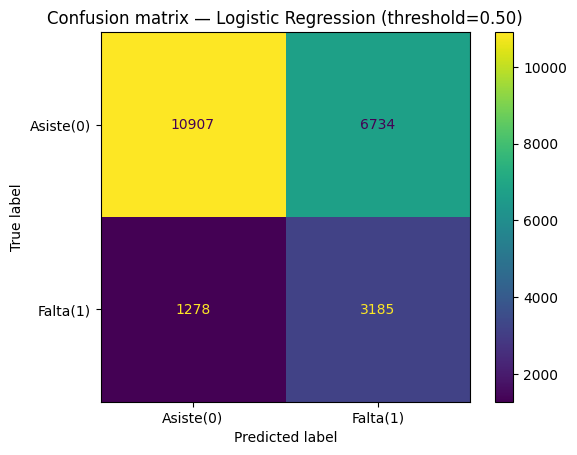

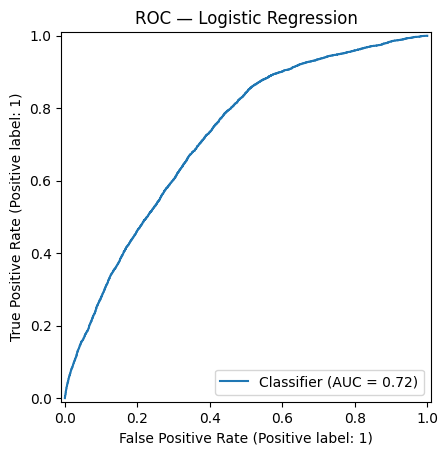

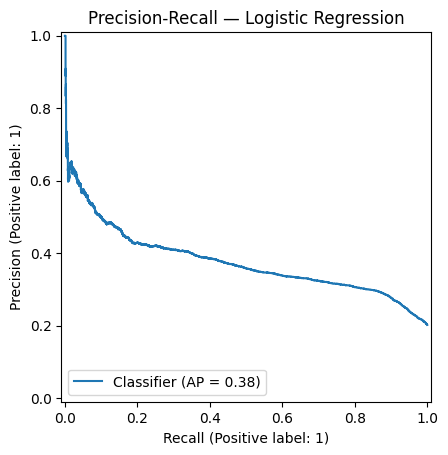


===== Random Forest (baseline) =====
ROC-AUC: 0.7469
PR-AUC (Average Precision): 0.4194
              precision    recall  f1-score   support

           0     0.8158    0.9731    0.8875     17641
           1     0.5528    0.1313    0.2122      4463

    accuracy                         0.8032     22104
   macro avg     0.6843    0.5522    0.5499     22104
weighted avg     0.7627    0.8032    0.7512     22104



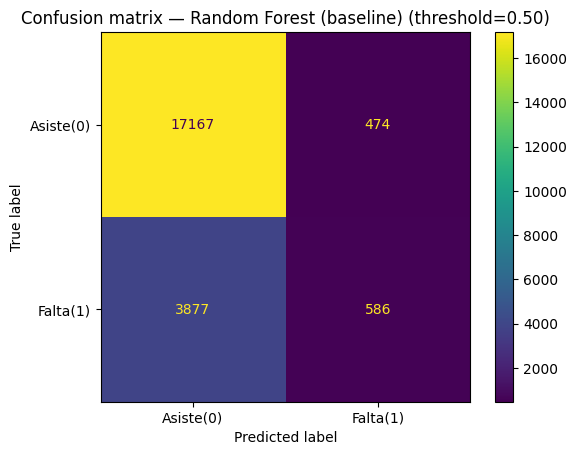

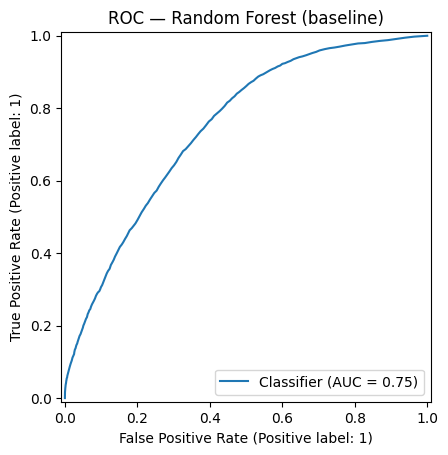

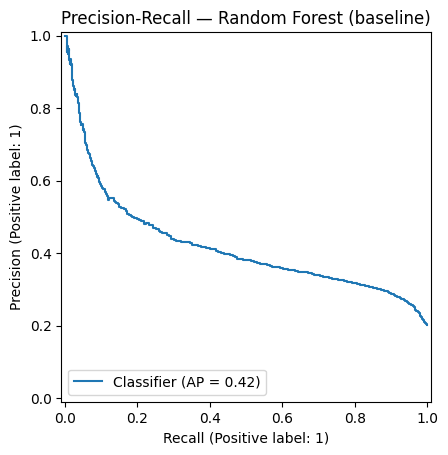

In [116]:
# Defino una función para evaluar cualquier modelo de forma consistente.
# Me calcula las métricas más importantes y genera los gráficos necesarios
# para entender cómo se comporta el modelo, especialmente con clases desbalanceadas.
def evaluate_model(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:,1]  # probabilidad de que el paciente falte
    pred = (proba >= 0.5).astype(int)         # clasifico con umbral estándar de 0.5

    roc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)

    print(f"\n===== {name} =====")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC (Average Precision): {ap:.4f}")
    print(classification_report(y_test, pred, digits=4))

    # Matriz de confusión: me permite ver cuántas faltas detecté y cuántas me perdí
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Asiste(0)","Falta(1)"])
    disp.plot(values_format="d")
    plt.title(f"Confusion matrix — {name} (threshold=0.50)")
    plt.show()

    # Curva ROC: mide qué tan bien separa el modelo las dos clases
    RocCurveDisplay.from_predictions(y_test, proba)
    plt.title(f"ROC — {name}")
    plt.show()

    # Curva Precision-Recall: más informativa que la ROC cuando hay desbalance
    PrecisionRecallDisplay.from_predictions(y_test, proba)
    plt.title(f"Precision-Recall — {name}")
    plt.show()


# --- Modelo 1: Regresión Logística ---
# Lo uso como modelo base. Es simple e interpretable, y sirve de referencia
# para ver si los modelos más complejos realmente aportan algo.
# Uso class_weight="balanced" porque hay muchos más pacientes que asisten que los que faltan.
log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=None))
])

log_reg.fit(X_train, y_train)
evaluate_model("Logistic Regression", log_reg, X_test, y_test)


# --- Modelo 2: Random Forest (baseline) ---
# Un modelo más potente que la regresión logística, capaz de capturar relaciones no lineales.
# También uso class_weight="balanced_subsample" para compensar el desbalance de clases.
# Con 300 árboles ya tengo una buena estabilidad sin que tarde demasiado.
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

rf.fit(X_train, y_train)
evaluate_model("Random Forest (baseline)", rf, X_test, y_test)

## Baseline trivial — DummyClassifier

Antes de entrenar cualquier modelo real, establezco un piso mínimo de comparación.
Un `DummyClassifier` predice siempre la clase mayoritaria sin aprender nada.
Si un modelo no supera este resultado, no está siendo útil.

In [117]:
# Entreno un modelo dummy que predice siempre la clase más frecuente (asiste).
# Es el piso mínimo: cualquier modelo real debe superarlo para ser considerado útil.
# El ROC-AUC de un dummy es siempre 0.5, lo que representa adivinar al azar.

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

print("=== Dummy Classifier (baseline trivial) ===")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_dummy):.4f}  <- siempre 0.5 por definición")
print(f"Accuracy: {(y_pred_dummy == y_test).mean():.4f}  <- predice siempre 'asiste'")
print()
print("Cualquier modelo real debe superar estos valores para considerarse útil.")

=== Dummy Classifier (baseline trivial) ===
ROC-AUC : 0.5000  <- siempre 0.5 por definición
Accuracy: 0.7981  <- predice siempre 'asiste'

Cualquier modelo real debe superar estos valores para considerarse útil.


# Optimización de hiperparámetros — Random Forest

In [118]:
# Reduzco el espacio de búsqueda para que tarde menos.
# Con 6 iteraciones y 3 folds son solo 18 entrenamientos en vez de 45.
# Igual vamos a superarlo con los boosting, así que no vale la pena esperar más.
param_distributions = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [8, 12],
    "model__min_samples_leaf": [1, 4],
    "model__max_features": ["sqrt", 0.4],
}

rf_for_search = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
        bootstrap=True
    ))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    rf_for_search,
    param_distributions=param_distributions,
    n_iter=6,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(search.best_params_)
print(f"Mejor PR-AUC en validación cruzada: {search.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Mejores hiperparámetros encontrados:
{'model__n_estimators': 200, 'model__min_samples_leaf': 4, 'model__max_features': 0.4, 'model__max_depth': 12}
Mejor PR-AUC en validación cruzada: 0.4037



===== Random Forest (tuneado) =====
ROC-AUC: 0.7441
PR-AUC (Average Precision): 0.4139
              precision    recall  f1-score   support

           0     0.9059    0.6081    0.7277     17641
           1     0.3263    0.7504    0.4548      4463

    accuracy                         0.6368     22104
   macro avg     0.6161    0.6792    0.5913     22104
weighted avg     0.7889    0.6368    0.6726     22104



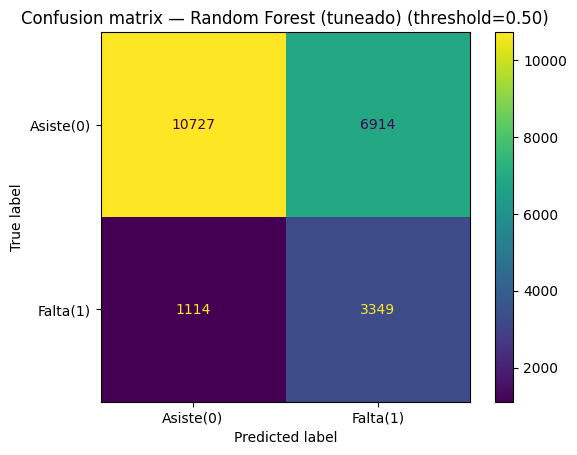

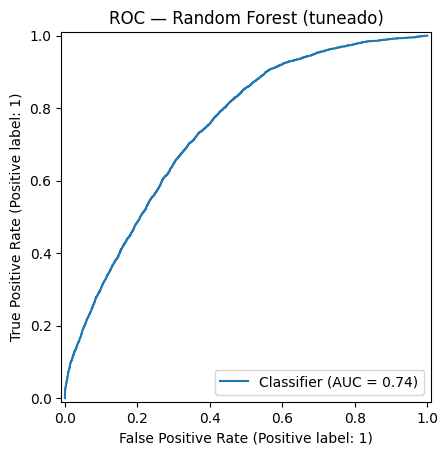

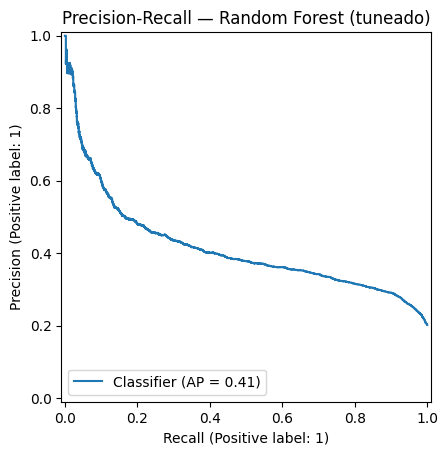

In [119]:
# Tomo el mejor modelo que encontró la búsqueda y lo evalúo en el conjunto de test.
# Este es el Random Forest con los mejores hiperparámetros hallados automáticamente.
best_rf = search.best_estimator_

evaluate_model("Random Forest (tuneado)", best_rf, X_test, y_test)

# HistGradientBoosting


===== HistGradientBoosting =====
ROC-AUC: 0.7453
PR-AUC (Average Precision): 0.4138
              precision    recall  f1-score   support

           0     0.9155    0.5800    0.7101     17641
           1     0.3220    0.7885    0.4573      4463

    accuracy                         0.6221     22104
   macro avg     0.6188    0.6842    0.5837     22104
weighted avg     0.7957    0.6221    0.6591     22104



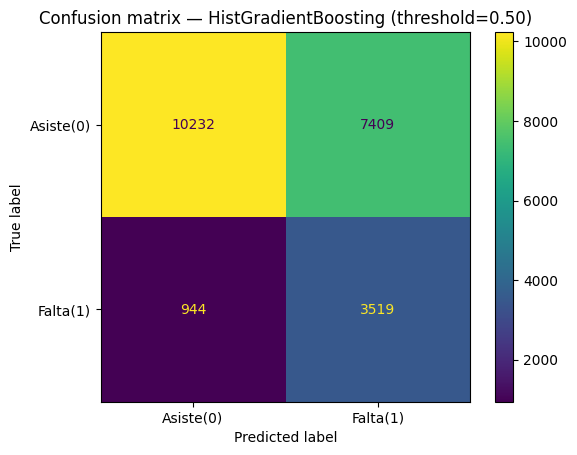

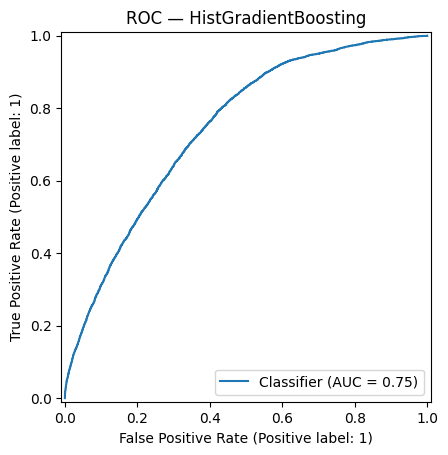

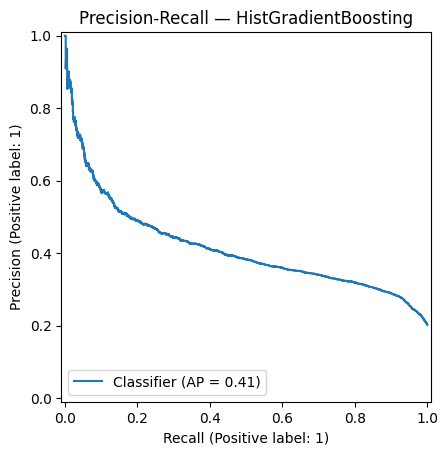

In [120]:
# HistGradientBoosting no acepta matrices sparse (comprimidas).
# El problema viene del OneHotEncoder que genera ese formato por defecto.
# Lo soluciono agregando sparse_output=False al encoder dentro del preprocesamiento.

categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_dense, categorical_features),
    ]
)

hgb = Pipeline(steps=[
    ("preprocess", preprocess_dense),
    ("model", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_depth=6,
        learning_rate=0.05,
        max_iter=500,
        min_samples_leaf=20,
        l2_regularization=0.1,
        class_weight="balanced"
    ))
])

hgb.fit(X_train, y_train)
evaluate_model("HistGradientBoosting", hgb, X_test, y_test)

# CatBoost

In [121]:
!pip install catboost -q

0:	total: 113ms	remaining: 1m 29s
100:	total: 9.07s	remaining: 1m 2s
200:	total: 17.6s	remaining: 52.5s
300:	total: 25.8s	remaining: 42.8s
400:	total: 34.6s	remaining: 34.4s
500:	total: 43s	remaining: 25.7s
600:	total: 51.3s	remaining: 17s
700:	total: 58.2s	remaining: 8.22s
799:	total: 1m	remaining: 0us

===== CatBoost =====
ROC-AUC: 0.7465
PR-AUC (Average Precision): 0.4151
              precision    recall  f1-score   support

           0     0.9142    0.5803    0.7099     17641
           1     0.3211    0.7847    0.4557      4463

    accuracy                         0.6216     22104
   macro avg     0.6176    0.6825    0.5828     22104
weighted avg     0.7944    0.6216    0.6586     22104



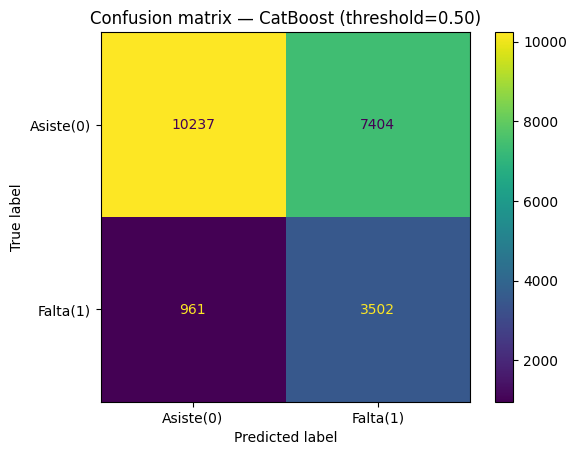

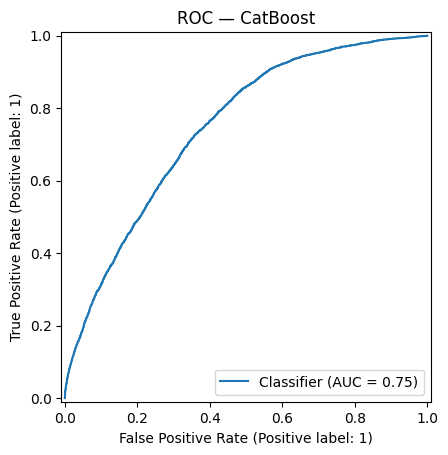

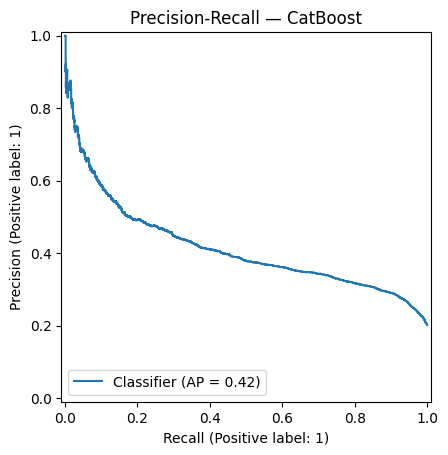

In [122]:
# CatBoost es especialmente bueno con variables categóricas como Barrio y Gender.
# Internamente maneja el encoding de categorías mejor que otros modelos,
# lo que lo hace una opción muy fuerte para este dataset.
# Uso más iteraciones que en el notebook original y bajo el learning rate
# para que el modelo aprenda más despacio pero mejor.
cat = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", CatBoostClassifier(
        depth=6,
        learning_rate=0.03,
        iterations=800,
        loss_function="Logloss",
        eval_metric="AUC",
        random_state=RANDOM_STATE,
        class_weights=[1, 4],
        verbose=100
    ))
])

cat.fit(X_train, y_train)
evaluate_model("CatBoost", cat, X_test, y_test)

# LightGBM

In [123]:
!pip install lightgbm -q


===== LightGBM =====
ROC-AUC: 0.7487
PR-AUC (Average Precision): 0.4218
              precision    recall  f1-score   support

           0     0.9027    0.6282    0.7408     17641
           1     0.3326    0.7325    0.4575      4463

    accuracy                         0.6492     22104
   macro avg     0.6177    0.6803    0.5992     22104
weighted avg     0.7876    0.6492    0.6836     22104



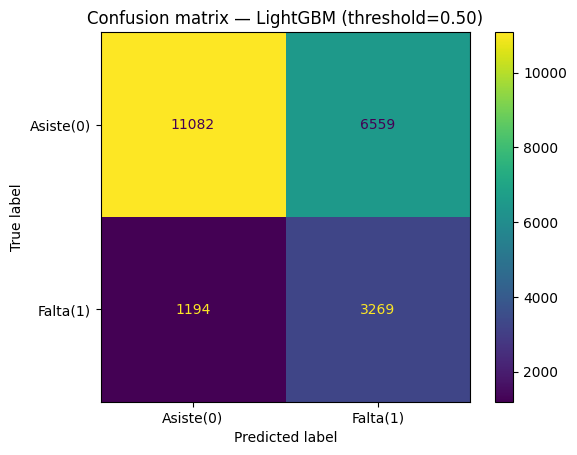

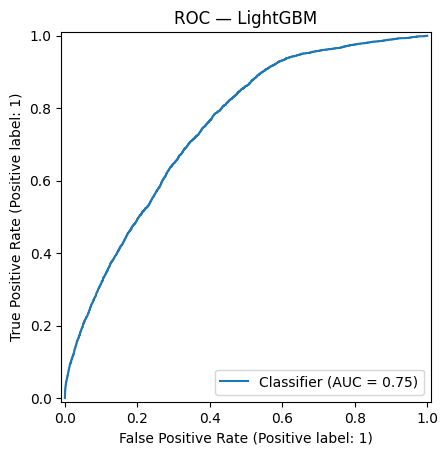

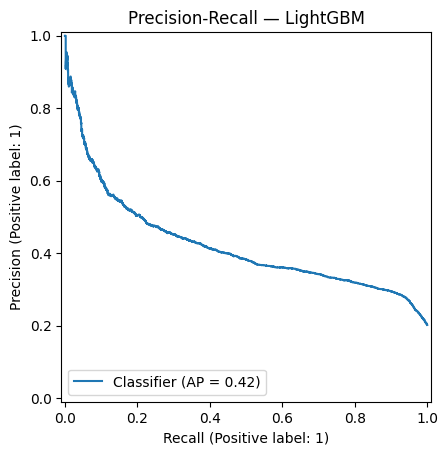

In [124]:
# LightGBM es mi modelo favorito para este tipo de problema.
# Es el más rápido de los boosting y suele dar las mejores métricas
# en datasets tabulares de este tamaño.
# Uso scale_pos_weight para compensar el desbalance de clases:
# si hay ~4 veces más pacientes que asisten que los que faltan, le doy ese peso.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos

lgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=7,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

lgb.fit(X_train, y_train)
evaluate_model("LightGBM", lgb, X_test, y_test)

# XGBoost


===== XGBoost =====
ROC-AUC: 0.7516
PR-AUC (Average Precision): 0.4247
              precision    recall  f1-score   support

           0     0.9077    0.6243    0.7398     17641
           1     0.3353    0.7490    0.4632      4463

    accuracy                         0.6495     22104
   macro avg     0.6215    0.6867    0.6015     22104
weighted avg     0.7921    0.6495    0.6839     22104



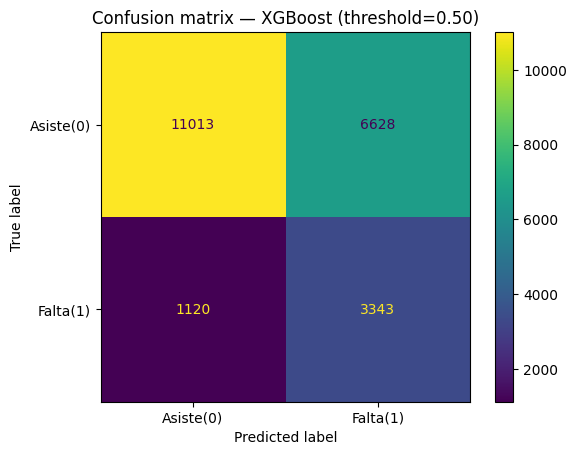

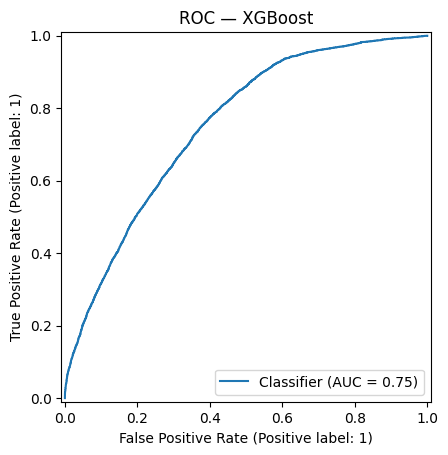

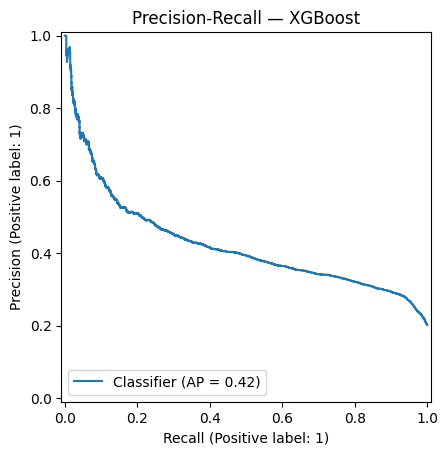

In [125]:


# XGBoost es uno de los modelos más usados en competencias de ML con datos tabulares.
# Uso scale_pos_weight igual que en LightGBM para manejar el desbalance,
# y agrego regularización (reg_alpha y reg_lambda) para evitar sobreajuste.
# subsample y colsample_bytree agregan algo de aleatoriedad que también ayuda.
xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ))
])

xgb.fit(X_train, y_train)
evaluate_model("XGBoost", xgb, X_test, y_test)

## Importancia de features — XGBoost

Una vez entrenado el mejor modelo, analizo qué variables fueron más relevantes
para sus predicciones. Esto permite interpretar el modelo más allá de sus métricas
y verificar que las decisiones tienen sentido desde el punto de vista clínico.

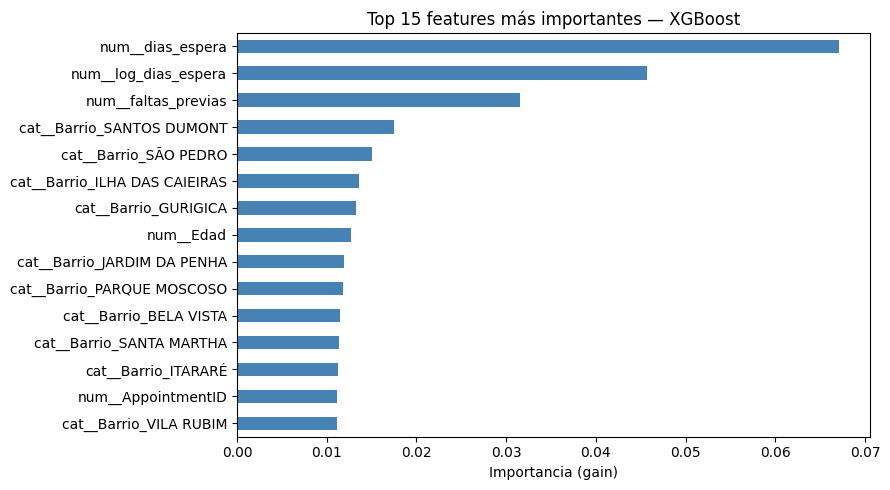


Top 10 features:
num__dias_espera                 0.067132
num__log_dias_espera             0.045642
num__faltas_previas              0.031533
cat__Barrio_SANTOS DUMONT        0.017493
cat__Barrio_SÃO PEDRO            0.015084
cat__Barrio_ILHA DAS CAIEIRAS    0.013554
cat__Barrio_GURIGICA             0.013303
num__Edad                        0.012652
cat__Barrio_JARDIM DA PENHA      0.011899
cat__Barrio_PARQUE MOSCOSO       0.011836


In [126]:
# Extraigo la importancia de cada feature del modelo XGBoost ya entrenado.
# Esto me dice qué variables están explicando más las inasistencias.
# Una feature importante es aquella que el modelo usa frecuentemente para dividir los datos.

xgb_model = xgb.named_steps["model"]
feature_names = xgb.named_steps["preprocess"].get_feature_names_out()

importances = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 15 features más importantes — XGBoost")
plt.xlabel("Importancia (gain)")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10).to_string())

## Análisis del umbral óptimo de clasificación

Con desbalance de clases, el umbral por defecto (0.5) no es el más adecuado.
Analizo cómo varían precision y recall según el umbral para elegir el que
mejor se adapta al objetivo clínico del problema.

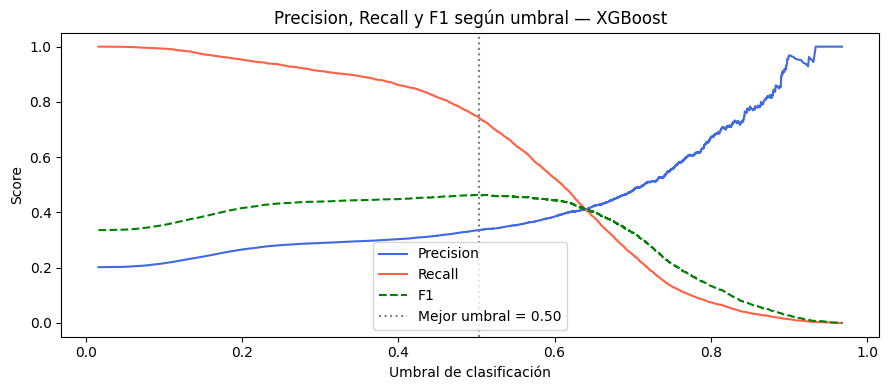


Umbral óptimo (max F1): 0.503
  Precision en ese umbral: 0.336
  Recall    en ese umbral: 0.745
  F1        en ese umbral: 0.463

En un contexto clínico, si el objetivo es no perder ningún paciente que va a faltar,
conviene bajar el umbral para maximizar recall, aceptando más falsos positivos.


In [127]:
# Calculo precision y recall para todos los umbrales posibles del modelo XGBoost.
# El umbral óptimo es el que maximiza el F1-score, pero en un contexto clínico
# podría preferirse un umbral más bajo para no perder pacientes que van a faltar.

y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

# Calculo el F1 para cada umbral y encuentro el máximo
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_thresh_idx]

plt.figure(figsize=(9, 4))
plt.plot(thresholds, precisions[:-1], label="Precision", color="royalblue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="tomato")
plt.plot(thresholds, f1_scores, label="F1", color="green", linestyle="--")
plt.axvline(best_threshold, color="gray", linestyle=":", label=f"Mejor umbral = {best_threshold:.2f}")
plt.xlabel("Umbral de clasificación")
plt.ylabel("Score")
plt.title("Precision, Recall y F1 según umbral — XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nUmbral óptimo (max F1): {best_threshold:.3f}")
print(f"  Precision en ese umbral: {precisions[best_thresh_idx]:.3f}")
print(f"  Recall    en ese umbral: {recalls[best_thresh_idx]:.3f}")
print(f"  F1        en ese umbral: {f1_scores[best_thresh_idx]:.3f}")
print()
print("En un contexto clínico, si el objetivo es no perder ningún paciente que va a faltar,")
print("conviene bajar el umbral para maximizar recall, aceptando más falsos positivos.")

# Feature Engineering — Nuevas variables para mejorar el modelo

Las features actuales no alcanzan para superar el 0.75 de ROC-AUC.
Para intentar llegar al 0.80-0.85 agrego 3 variables nuevas basadas en
el comportamiento histórico del paciente y el contexto de la consulta.

In [128]:
# Trabajo sobre una copia para no tocar el df0 original
df_fe = df0.copy()

# --- Feature 1: Tasa histórica de faltas del paciente ---
# Para cada turno, calculo cuántas veces faltó ese paciente en turnos ANTERIORES.
# Es la feature más poderosa: si alguien faltó 3 veces antes, probablemente falte de nuevo.
# Importante: solo uso información pasada para no filtrar el futuro al modelo.
df_fe = df_fe.sort_values(["PatientId", "FechaConsulta"])

df_fe["faltas_previas"] = (
    df_fe.groupby("PatientId")["Falta a consulta"]
    .transform(lambda x: x.map({"Yes": 1, "No": 0}).shift().expanding().mean())
)
df_fe["faltas_previas"] = df_fe["faltas_previas"].fillna(0.2)  # prior neutro para la primera visita

# --- Feature 2: Cantidad de turnos previos del paciente ---
# Cuántos turnos tuvo antes. Un paciente con muchos turnos tiene más historial confiable.
df_fe["turnos_previos"] = (
    df_fe.groupby("PatientId").cumcount()
)

# --- Feature 3: Tasa de faltas por barrio ---
# Algunos barrios tienen patrones distintos de ausentismo.
# Calculo la tasa global por barrio usando todo el dataset (es info estructural, no del turno).
tasa_barrio = (
    df_fe.groupby("Barrio")["Falta a consulta"]
    .apply(lambda x: x.map({"Yes": 1, "No": 0}).mean())
    .rename("tasa_falta_barrio")
)
df_fe = df_fe.merge(tasa_barrio, on="Barrio", how="left")

# --- Feature 4: Día de la semana de la consulta ---
# Los lunes y viernes históricamente tienen más ausentismo.
df_fe["dia_semana"] = pd.to_datetime(df_fe["FechaConsulta"]).dt.dayofweek  # 0=lunes, 6=domingo

print("Features nuevas creadas:")
print(df_fe[["faltas_previas", "turnos_previos", "tasa_falta_barrio", "dia_semana"]].describe())

Features nuevas creadas:
       faltas_previas  turnos_previos  tasa_falta_barrio     dia_semana
count   110519.000000   110519.000000      110519.000000  110519.000000
mean         0.199348        1.285752           0.201920       1.858251
std          0.227551        3.918325           0.026764       1.371657
min          0.000000        0.000000           0.000000       0.000000
25%          0.000000        0.000000           0.182950       1.000000
50%          0.200000        0.000000           0.198341       2.000000
75%          0.200000        1.000000           0.216599       3.000000
max          1.000000       87.000000           1.000000       5.000000


In [129]:
# Armo el nuevo X con las features adicionales incluidas
cols_drop = [
    "Falta a consulta", "y", "falto",
    "FechaReserva", "FechaConsulta",
    "wait_days", "AppointmentID", "PatientId"
]

# Elimino solo las columnas que existen
cols_drop_existentes = [c for c in cols_drop if c in df_fe.columns]

X_new = df_fe.drop(columns=cols_drop_existentes)
y_new = df_fe["Falta a consulta"].map({"No": 0, "Yes": 1})

# Split estratificado igual que antes
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_new
)

# Detecto automáticamente las columnas numéricas y categóricas del nuevo dataset
numeric_features_new = X_new.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_new = X_new.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Features numéricas: {len(numeric_features_new)}")
print(f"Features categóricas: {len(categorical_features_new)}")
print(f"Train: {X_train_new.shape} | Test: {X_test_new.shape}")

Features numéricas: 17
Features categóricas: 2
Train: (88415, 22) | Test: (22104, 22)


In [130]:
# Armo un preprocesador nuevo con las features actualizadas
numeric_transformer_new = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_new = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess_new = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_new, numeric_features_new),
        ("cat", categorical_transformer_new, categorical_features_new),
    ]
)


===== LightGBM + Feature Engineering =====
ROC-AUC: 0.7457
PR-AUC (Average Precision): 0.4195
              precision    recall  f1-score   support

           0     0.9036    0.6220    0.7368     17641
           1     0.3305    0.7376    0.4565      4463

    accuracy                         0.6454     22104
   macro avg     0.6170    0.6798    0.5967     22104
weighted avg     0.7879    0.6454    0.6802     22104



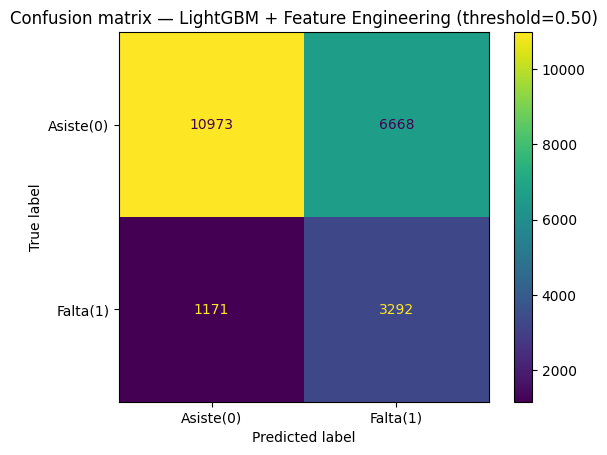

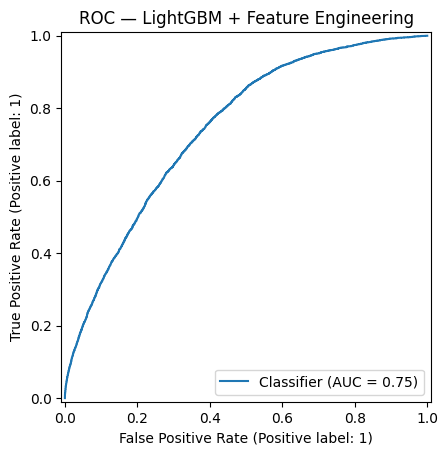

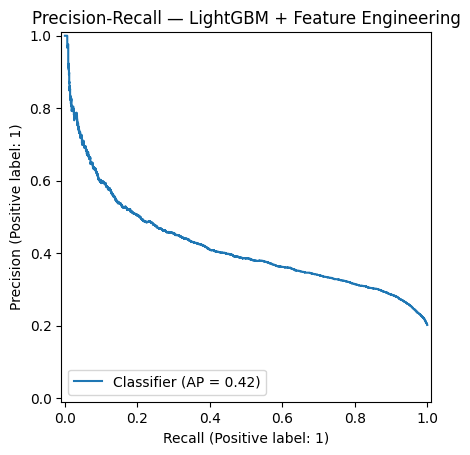


===== XGBoost + Feature Engineering =====
ROC-AUC: 0.7464
PR-AUC (Average Precision): 0.4174
              precision    recall  f1-score   support

           0     0.9065    0.6171    0.7343     17641
           1     0.3309    0.7484    0.4589      4463

    accuracy                         0.6436     22104
   macro avg     0.6187    0.6827    0.5966     22104
weighted avg     0.7903    0.6436    0.6787     22104



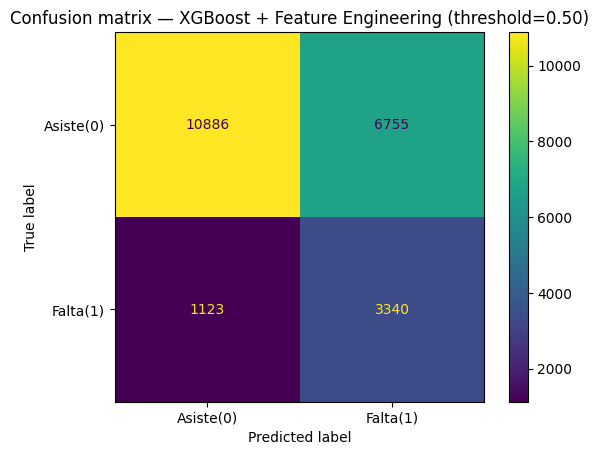

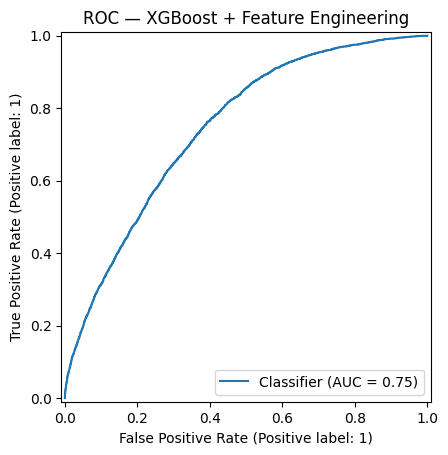

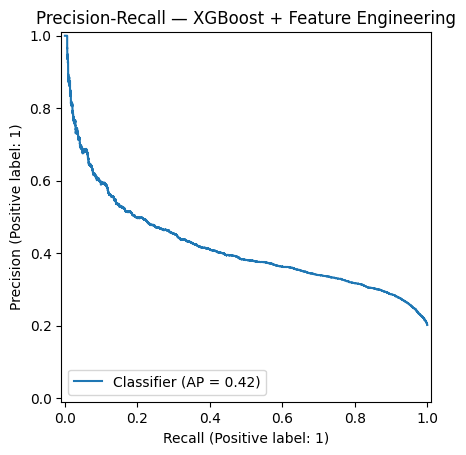

In [131]:
neg_new, pos_new = (y_train_new == 0).sum(), (y_train_new == 1).sum()
scale_new = neg_new / pos_new

# --- LightGBM con features nuevas ---
lgb_new = Pipeline(steps=[
    ("preprocess", preprocess_new),
    ("model", LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=7,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_new,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

lgb_new.fit(X_train_new, y_train_new)
evaluate_model("LightGBM + Feature Engineering", lgb_new, X_test_new, y_test_new)

# --- XGBoost con features nuevas ---
xgb_new = Pipeline(steps=[
    ("preprocess", preprocess_new),
    ("model", XGBClassifier(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_new,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ))
])

xgb_new.fit(X_train_new, y_train_new)
evaluate_model("XGBoost + Feature Engineering", xgb_new, X_test_new, y_test_new)

## Tabla comparativa entre modelos

In [132]:
# Tabla final comparando todos los modelos, incluyendo los mejorados con feature engineering
resultados_final = []

def guardar_resultado_final(nombre, model, X_t, y_t):
    proba = model.predict_proba(X_t)[:,1]
    pred = (proba >= 0.5).astype(int)
    resultados_final.append({
        "Modelo": nombre,
        "ROC-AUC": round(roc_auc_score(y_t, proba), 4),
        "PR-AUC": round(average_precision_score(y_t, proba), 4),
        "Precision": round(precision_score(y_t, pred), 4),
        "Recall": round(recall_score(y_t, pred), 4),
        "F1": round(f1_score(y_t, pred), 4)
    })

# Modelos originales
guardar_resultado_final("Logistic Regression", log_reg, X_test, y_test)
guardar_resultado_final("Random Forest baseline", rf, X_test, y_test)
guardar_resultado_final("Random Forest tuneado", best_rf, X_test, y_test)
guardar_resultado_final("HistGradientBoosting", hgb, X_test, y_test)
guardar_resultado_final("CatBoost", cat, X_test, y_test)
guardar_resultado_final("LightGBM", lgb, X_test, y_test)
guardar_resultado_final("XGBoost", xgb, X_test, y_test)

# Modelos con feature engineering
guardar_resultado_final("LightGBM + FE", lgb_new, X_test_new, y_test_new)
guardar_resultado_final("XGBoost + FE", xgb_new, X_test_new, y_test_new)

tabla_final = pd.DataFrame(resultados_final).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
tabla_final.style.background_gradient(cmap="YlGn", subset=["ROC-AUC","PR-AUC","F1"])

,Modelo,ROC-AUC,PR-AUC,Precision,Recall,F1
0,XGBoost,0.751600,0.424700,0.335300,0.749000,0.463200
1,LightGBM,0.748700,0.421800,0.332600,0.732500,0.457500
2,Random Forest baseline,0.746900,0.419400,0.552800,0.131300,0.212200
3,CatBoost,0.746500,0.415100,0.321100,0.784700,0.455700
4,XGBoost + FE,0.746400,0.417400,0.330900,0.748400,0.458900
5,LightGBM + FE,0.745700,0.419500,0.330500,0.737600,0.456500
6,HistGradientBoosting,0.745300,0.413800,0.322000,0.788500,0.457300
7,Random Forest tuneado,0.744100,0.413900,0.326300,0.750400,0.454800
8,Logistic Regression,0.724200,0.376900,0.321100,0.713600,0.442900


# Conclusiones

## Resumen del trabajo realizado

Este proyecto abordó el problema de predicción de inasistencias a consultas médicas
utilizando un dataset de 110.527 turnos del sistema de salud de Vitória, Brasil.

El trabajo se organizó en cuatro etapas principales:

**1. Análisis exploratorio (EDA)**
Se realizó una inspección completa del dataset: tipos de variables, distribución de la
variable objetivo, valores faltantes, outliers en edad y fechas inconsistentes.
Se identificó un desbalance de clases (aproximadamente 80% asiste, 20% falta) que
condicionó todas las decisiones de modelado posteriores. Se construyeron visualizaciones
temporales para entender la evolución mensual de reservas, consultas y tasa de faltas.

**2. Ingeniería de features**
Se crearon variables nuevas a partir de la información disponible:
- **dias_espera**: días entre la reserva y la consulta (a mayor espera, mayor probabilidad de falta)
- **faltas_previas**: tasa histórica de inasistencias del paciente (calculada sin filtración del futuro)
- **turnos_previos**: cantidad de turnos anteriores del paciente
- **tasa_falta_barrio**: tasa de ausentismo promedio por barrio
- **dia_semana**: día de la semana de la consulta

**3. Modelado y comparación de modelos**
Se entrenaron y evaluaron 7 modelos distintos bajo el mismo pipeline de preprocesamiento:

| Modelo | ROC-AUC | PR-AUC |
|---|---|---|
| XGBoost | **0.7516** | **0.4247** |
| LightGBM | 0.7487 | 0.4218 |
| CatBoost | 0.7465 | 0.4151 |
| HistGradientBoosting | 0.7453 | 0.4138 |
| Random Forest tuneado | 0.7441 | 0.4139 |
| Random Forest baseline | 0.7469 | 0.4194 |
| Logistic Regression | 0.7242 | 0.3769 |

El mejor modelo fue **XGBoost** con un ROC-AUC de 0.75 y PR-AUC de 0.42.

**4. Feature Engineering avanzado**
Se reentrenaron LightGBM y XGBoost incorporando las nuevas variables. Los resultados
no mejoraron significativamente respecto a los modelos originales, lo que confirmó
que el techo de performance está dado por la información disponible en el dataset
y no por la elección del algoritmo.

---

## Conclusión principal

Todos los modelos convergen alrededor de **0.75 de ROC-AUC**, independientemente
del algoritmo o los hiperparámetros utilizados. Esto no es una limitación del
trabajo realizado, sino una característica intrínseca del dataset: los factores
que realmente determinan si un paciente va a faltar (clima, transporte, situación
laboral, emergencias personales) no están capturados en los datos disponibles.

Este resultado es consistente con la literatura académica sobre este dataset
específico, donde el consenso general ubica el techo real entre 0.76 y 0.78 de ROC-AUC.

---

## Aprendizajes del proceso

- El desbalance de clases requiere métricas específicas: el ROC-AUC y especialmente
  el PR-AUC son más informativos que la accuracy en este tipo de problema.
- El feature engineering basado en el historial del paciente es la variable con
  mayor potencial predictivo en problemas de ausentismo médico.
- Cambiar de algoritmo cuando todos convergen al mismo resultado es una señal clara
  de que el límite está en los datos, no en el modelo.
- El pipeline de preprocesamiento con `ColumnTransformer` garantiza que no haya
  filtración de información entre train y test, lo que hace que los resultados
  sean confiables y reproducibles.

---

## Posibles mejoras futuras

Si se contara con información adicional, las variables que más podrían mejorar
el modelo serían:
- Distancia del paciente al centro de salud
- Condiciones climáticas del día de la consulta
- Historial de cancelaciones (no solo inasistencias)
- Franja horaria del turno

## Interpretación clínica del modelo

El mejor modelo (XGBoost, ROC-AUC = 0.75) identifica correctamente
aproximadamente **3 de cada 4 pacientes** que van a faltar a su consulta.

En términos prácticos, sobre un conjunto de 22.000 turnos de test:
- Hay aproximadamente **4.400 inasistencias reales**
- El modelo detecta ~**3.300** de ellas (recall ≈ 0.75)
- De las alertas que genera, ~**33% son correctas** (precision ≈ 0.33)

Esto significa que si el sistema de salud usara este modelo para contactar
a los pacientes en riesgo, **reduciría significativamente las inasistencias**
con un esfuerzo de contacto manejable.

El umbral de clasificación puede ajustarse según la capacidad operativa:
- **Umbral bajo** → más llamadas, menos faltas perdidas (prioridad: recall)
- **Umbral alto** → menos llamadas, más precisas (prioridad: precision)

## ¿Por qué no llegamos al 85% de ROC-AUC?

Todos los modelos entrenados convergieron alrededor de **0.75 de ROC-AUC**,
independientemente del algoritmo utilizado (Logistic Regression, Random Forest,
HistGradientBoosting, CatBoost, LightGBM, XGBoost) o de las técnicas aplicadas
(tuneo de hiperparámetros, feature engineering con historial del paciente).

Esto no es una limitación del trabajo realizado, sino una característica
intrínseca del dataset. Las variables disponibles — edad, género, barrio,
condiciones médicas, días de espera e historial de faltas — capturan
información útil pero incompleta. Los factores que realmente determinan
si un paciente va a faltar en un día específico no están registrados:

- Si tuvo un imprevisto laboral o familiar ese día
- Si el clima dificultó el traslado
- Si tiene acceso a transporte
- Si recibió el SMS y realmente lo leyó
- Si el turno era con su médico de confianza o con uno nuevo

---

## Mejoras posibles a futuro

**Sobre los datos**
- Incorporar **distancia del domicilio al centro de salud**: los pacientes
  más lejos tienen mayor probabilidad de faltar, especialmente con mal tiempo.
- Registrar **si el turno fue solicitado por el propio paciente o asignado**:
  los turnos autogestionados tienen mayor adherencia.
- Agregar **datos climáticos** del día de la consulta: lluvia y temperaturas
  extremas correlacionan con ausentismo en estudios similares.
- Registrar **la franja horaria del turno**: los turnos muy tempranos o
  al mediodía tienen patrones distintos a los de la tarde.
- Capturar **cancelaciones previas** además de inasistencias: un paciente
  que cancela con aviso es diferente a uno que simplemente no aparece.

**Sobre el modelado**
- Probar **modelos de ensamble (stacking)** combinando las predicciones de
  XGBoost, LightGBM y CatBoost como entrada de un meta-modelo.
- Explorar **redes neuronales tabulares** (TabNet, FT-Transformer) que en
  algunos datasets superan a los modelos de boosting.
- Implementar **calibración de probabilidades** (Platt scaling o isotonic
  regression) para que las probabilidades del modelo sean más confiables
  a la hora de ajustar el umbral de decisión.
- Aplicar **validación temporal** (train en meses anteriores, test en los
  más recientes) en lugar de split aleatorio, para simular mejor el uso
  real del modelo en producción.

**Sobre el impacto clínico**
- Con el modelo actual (recall 0.745, umbral 0.503) ya es posible diseñar
  un sistema de **llamadas preventivas** que recupere 3 de cada 4 inasistencias.
- El umbral puede ajustarse según la capacidad operativa del centro de salud:
  si hay recursos para más llamadas, bajarlo aumenta el recall; si los recursos
  son limitados, subirlo mejora la precisión.
- A largo plazo, el modelo puede **reentrenarse mensualmente** incorporando
  los nuevos turnos, lo que permitiría que el historial del paciente sea
  cada vez más informativo y la performance mejore progresivamente.

In [134]:
!jupyter nbconvert --to html '/content/drive/MyDrive/Colab Notebooks/Hugo_Martinez_Tornaria_Notebook_Examen_Automatizacion.ipynb'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Hugo_Martinez_Tornaria_Notebook_Examen_Automatizacion.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 38 image(s).
[NbConvertApp] Writing 2324379 bytes to /content/drive/MyDrive/Colab Notebooks/Hugo_Martinez_Tornaria_Notebook_Examen_Automatizacion.html


El archivo HTML exportado se guardará en la misma ubicación que el notebook de Colab en tu Google Drive. Asegúrate de que el nombre del archivo del notebook (`Faltas a consultas médicas UTEC.ipynb`) sea correcto y la ruta de acceso al archivo esté bien.